# Business Case

* No-Churn Telecom is an established Telecom operator in Europe
with more than a decade in Business. Due to new players in the
market, telecom industry has become very competitive and
retaining customers becoming a challenge.
* In spite of No-Churn initiatives of reducing tariffs and promoting
more offers, the churn rate ( percentage of customers migrating to
competitors) is well above 10%.
* No-Churn wants to explore possibility of Machine Learning to help
with following use cases to retain competitive edge in the industry.

## Domain Analysis

**Importing necessary libraries**

In [1]:
# import the total python libraries for this project
import os               # Handling the Current Working Directory
import mysql.connector  #  mysql-connector for making connections to database server
import numpy as np  # use for numerical function
import pandas as pd  # use for data cleaning and data analysis
import matplotlib.pyplot as plt  # use data visualization
import seaborn as sb  # use for data visualization
import warnings # use for warnings the ignore
warnings.filterwarnings("ignore") # call the warning

In [3]:
# connection = mysql.connector.connect(host = "18.136.157.135",
#                                      user= 'dm_team3',
#                                      password = 'DM!$!Team!27@9!20&')

In [5]:
# cursor=connection.cursor()
# cursor.execute('show databases')
# for i in cursor:
#     print(i)

In [7]:
# connection=mysql.connector.connect(host = "18.136.157.135",
#                                    user= 'dm_team3',
#                                    password = 'DM!$!Team!27@9!20&',
#                                    database='project_telecom')

In [9]:
# db_tables = pd.read_sql_query('show tables',connection)
# print(db_tables)

In [11]:
# data = pd.read_sql_query("Select * from telecom_churn_data",connection)

In [13]:
# data.to_csv('PRCL-0017 Customer Churn.csv')

In [3]:
data1 = pd.read_csv('PRCL-0017 Customer Churn.csv') #use for load the data

In [5]:
data1

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,...,112,15.91,158.6,122,7.14,8.5,6,2.30,3,False.
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,...,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,...,129,25.17,200.9,91,9.04,13.0,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,...,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.


## Atribute Information

- **State:** The state in which the customer resides.
- **Account Length:** The duration (in days) for which the customer has had an account.
- **Area Code:** The telephone area code of the customer.
- **Phone:** The phone number of the customer.
- **International Plan:** Indicates whether the customer has subscribed to an international calling plan (yes/no).
- **VMail Plan:** Indicates whether the customer has subscribed to a voice mail service (yes/no).
- **VMail Message:** The number of voice mail messages received by the customer.
- **Day Mins:** Total call minutes used during the day.
- **Day Calls:** Total number of calls made during the day.
- **Day Charge:** Total charges incurred for daytime calls.
- **Eve Mins:** Total call minutes used during the evening.
- **Eve Calls:** Total number of calls made during the evening.
- **Eve Charge:** Total charges incurred for evening calls.
- **Night Mins:** Total call minutes used during the night.
- **Night Calls:** Total number of calls made during the night.
- **Night Charge:** Total charges incurred for nighttime calls.
- **International Mins:** Total international call minutes used.
- **International Calls:** Total number of international calls made.
- **International Charge:** Total charges incurred for international calls.
- **CustServ Calls:** The number of customer service calls made by the customer.
- **Churn:** The target variable indicating whether the customer has churned (True/False).

## Basic Check

In [9]:
data1.head() #showning the top 5 data

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [11]:
data1.tail() #showing the last 5 data

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,...,112,15.91,158.6,122,7.14,8.5,6,2.30,3,False.
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,...,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,...,129,25.17,200.9,91,9.04,13.0,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,...,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.
4616,IN,140,415,409-6884,no,no,0,204.7,100,34.80,...,107,10.78,202.8,115,9.13,12.1,4,3.27,2,False.


In [25]:
data1.describe() #use for continous column show information

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls
count,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000
mean,100.645224,437.046350,7.849903,180.447152,100.054364,30.676576,200.429088,100.179770,17.036703,200.623933,99.944120,9.028185,10.279294,4.433831,2.775926,1.567035
std,39.597194,42.288212,13.592333,53.983540,19.883027,9.177145,50.557001,19.821314,4.297332,50.543616,19.935053,2.274488,2.757361,2.457615,0.744413,1.307019
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,12.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,165.900000,87.000000,14.100000,167.100000,87.000000,7.520000,8.600000,3.000000,2.320000,1.000000
50%,100.000000,415.000000,0.000000,180.000000,100.000000,30.600000,200.800000,101.000000,17.070000,200.800000,100.000000,9.040000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,17.000000,216.800000,113.000000,36.860000,234.000000,114.000000,19.890000,234.900000,113.000000,10.570000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,351.500000,165.000000,59.760000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [13]:
data1['Churn'].unique()

array([' False.', ' True.'], dtype=object)

In [21]:
data1.Churn.value_counts()

Churn
False.    3961
True.      656
Name: count, dtype: int64

In [27]:
data1.describe(include="O") #use for categorical column show information

,State,Phone,International Plan,VMail Plan,Churn
count,4617,4617,4617,4617,4617
unique,51,4617,2,2,2
top,WV,382-4657,no,no,False.
freq,149,1,4171,3381,3961


- The average account length is approximately 100 days, with a maximum of 243 days, indicating varying levels of customer loyalty.
- Day Mins (average 180.4) and Eve Mins (average 200.4) show high usage compared to Night Mins (average 200.6), which might be influenced by tariff plans.
- Most customers do not use the international plan (only 446 out of 4617 do), and international call charges are relatively low.
- The Churn rate is around 14.3% (656 churned out of 4617), suggesting that churn is a significant problem for the company.
- The majority of customers (83%) make 1-3 customer service calls, which may reflect issues or dissatisfaction.

In [30]:
data1.info() #check the dataset column information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   State                  4617 non-null   object 
 1   Account Length         4617 non-null   int64  
 2   Area Code              4617 non-null   int64  
 3   Phone                  4617 non-null   object 
 4   International Plan     4617 non-null   object 
 5   VMail Plan             4617 non-null   object 
 6   VMail Message          4617 non-null   int64  
 7   Day Mins               4617 non-null   float64
 8   Day Calls              4617 non-null   int64  
 9   Day Charge             4617 non-null   float64
 10  Eve Mins               4617 non-null   float64
 11  Eve Calls              4617 non-null   int64  
 12  Eve Charge             4617 non-null   float64
 13  Night Mins             4617 non-null   float64
 14  Night Calls            4617 non-null   int64  
 15  Nigh

## EDA:- Exploratory Data Analysis

**Exploratory Data Analysis (EDA):-**  EDA in machine learning is the process of analyzing and visualizing datasets to summarize their main characteristics, often using statistical graphics and visualization techniques.\

**There is a Three types of EDA :-**
1. Univariant Analysis
2. Biavariant Analysis
3. Multivariant Analysis

In [34]:
# store the all column in one variable
for columns in data1: # use the of loop for store the dataset columns
    print(columns)

State
Account Length
Area Code
Phone
International Plan
VMail Plan
VMail Message
Day Mins
Day Calls
Day Charge
Eve Mins
Eve Calls
Eve Charge
Night Mins
Night Calls
Night Charge
International Mins
International calls  
International Charge
CustServ Calls
Churn


### Univariant Analysis

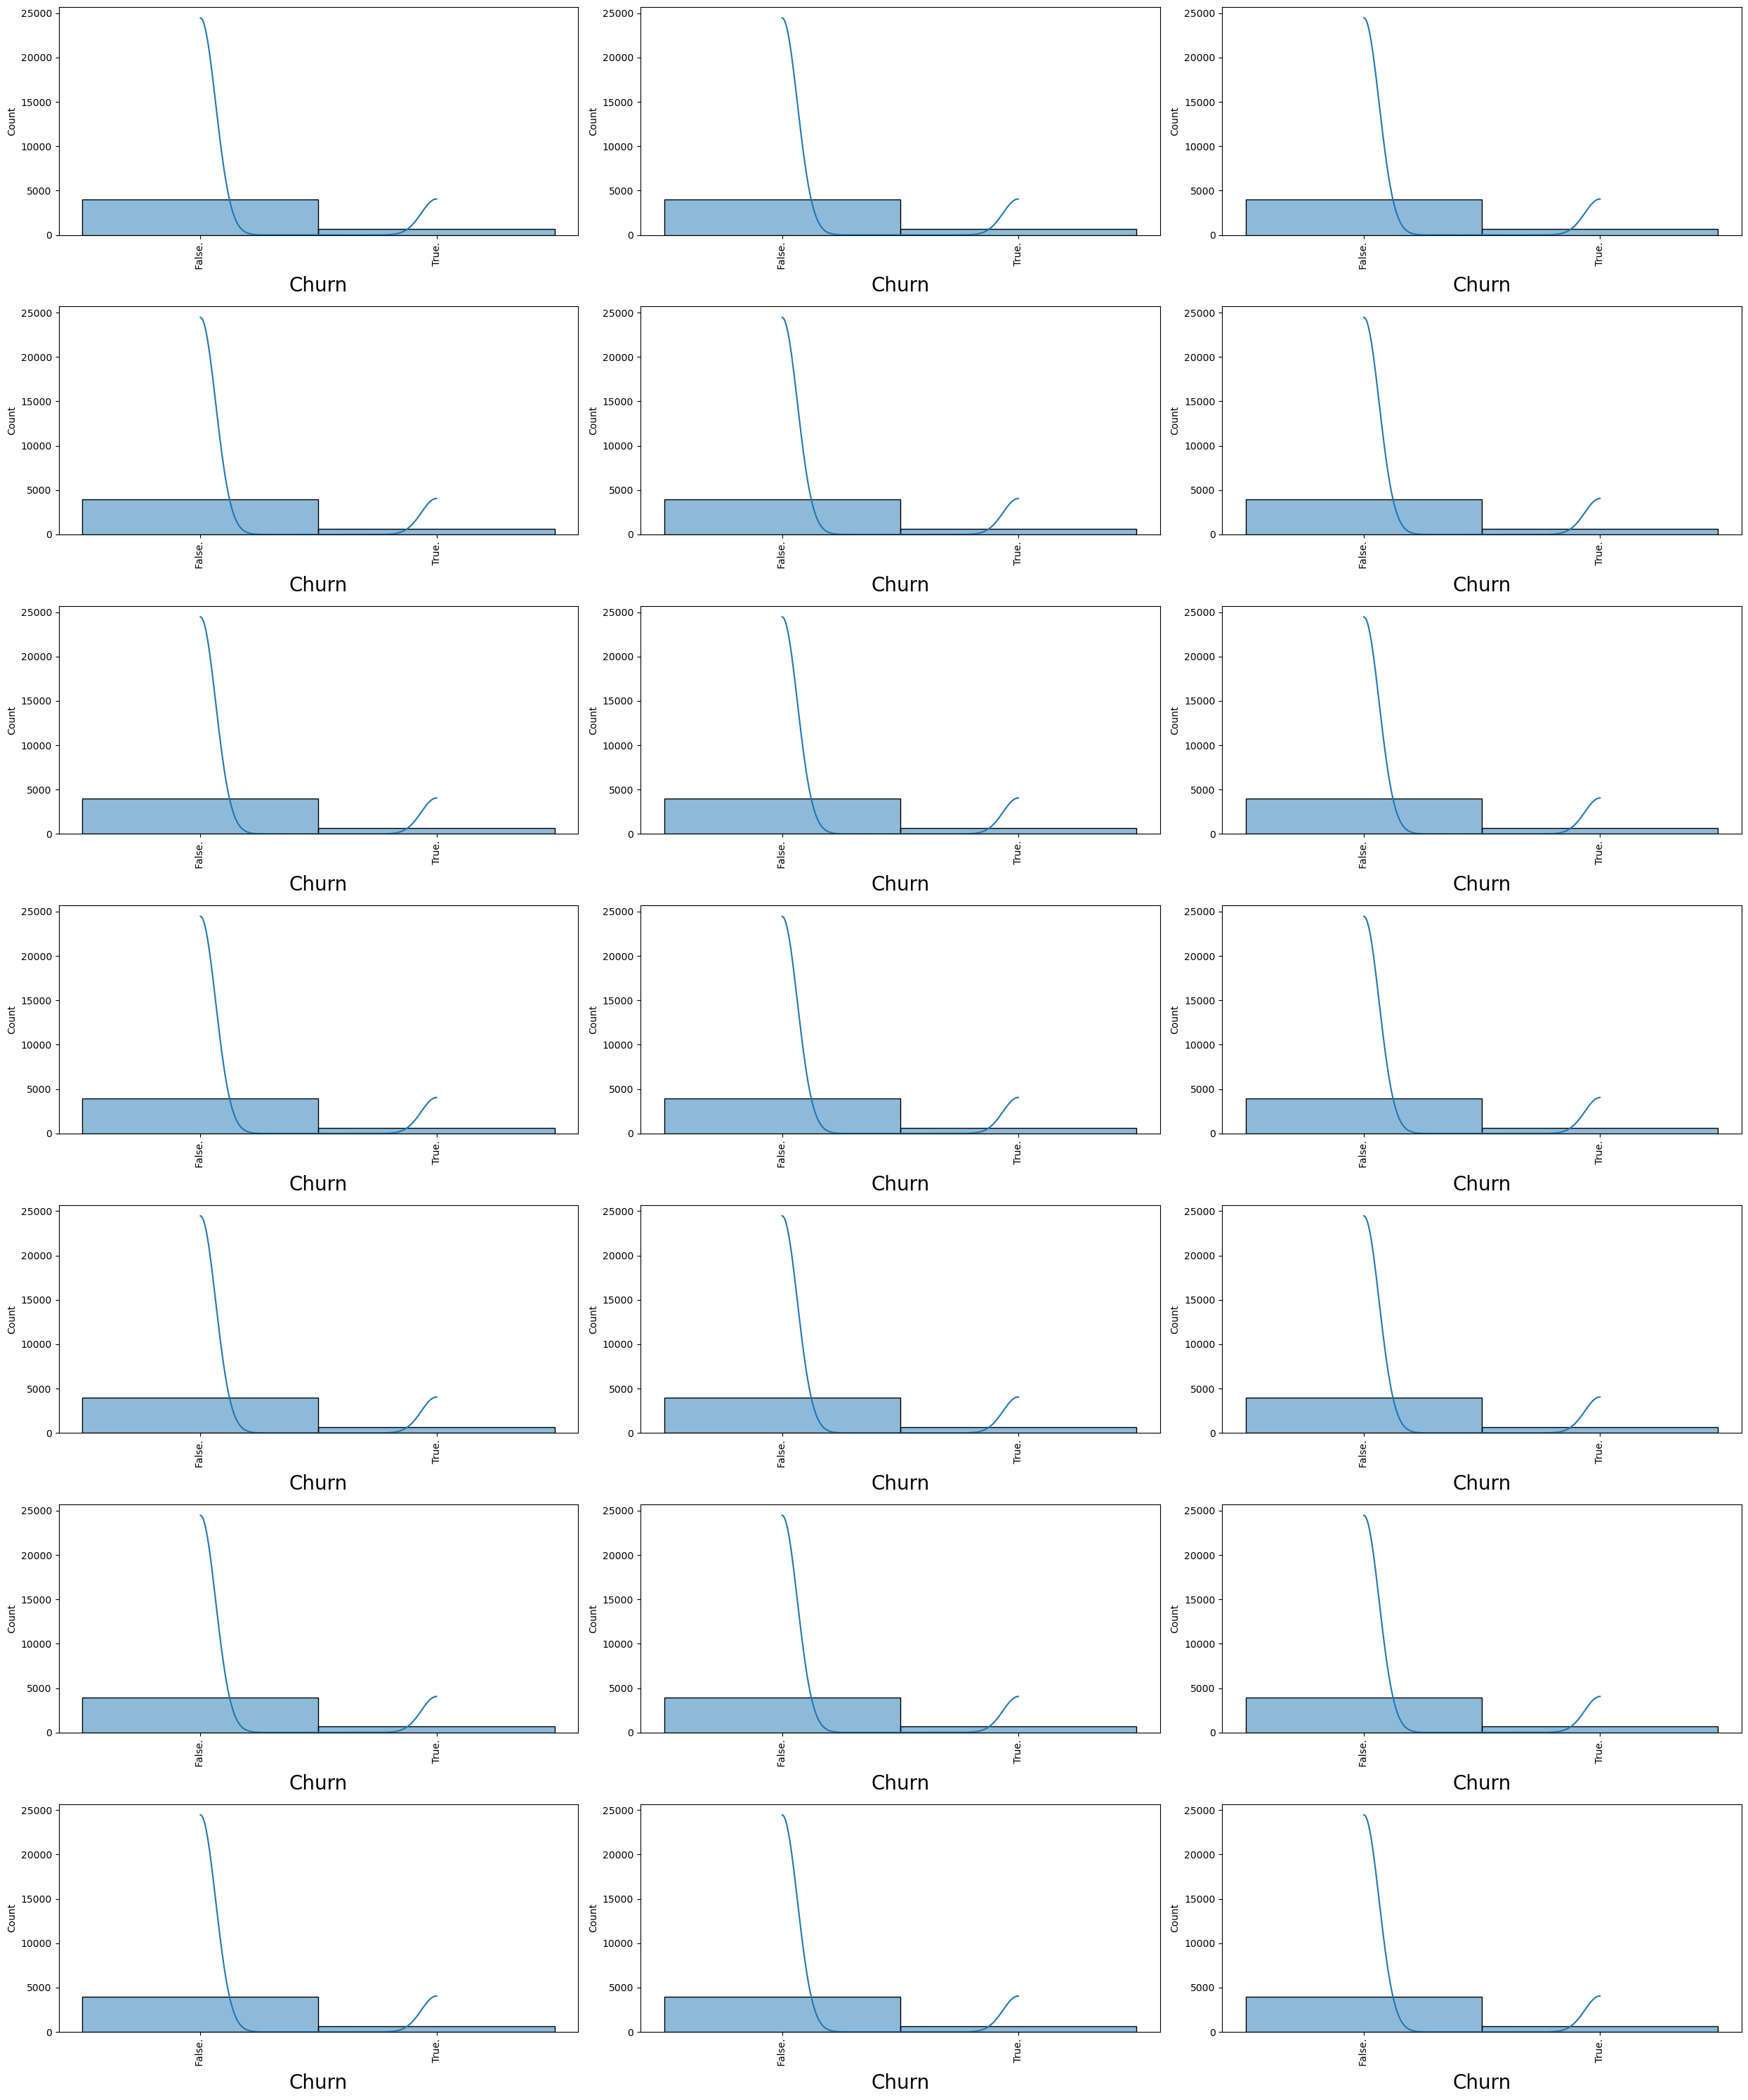

In [37]:
# Univeriant Analysis
plt.figure(figsize=(25,30))  # define the plot size
plt_num = 1
for column in data1:
    if plt_num <= 21: # assighn the column value
        plt.subplot(7,3,plt_num) # row and column assighn
        sb.histplot(data1[columns],kde=True) # create the histogram plot
        plt.xlabel(columns,fontsize = 20)
        plt.xticks(rotation = 90) # assighn the xlabel value
    plt_num += 1
plt.tight_layout() # use for data show function

### Biavarinat Analysis

In [39]:
data1.columns #show the columns

Index(['State', 'Account Length', 'Area Code', 'Phone', 'International Plan',
       'VMail Plan', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
       'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
       'Night Charge', 'International Mins', 'International calls  ',
       'International Charge', 'CustServ Calls', 'Churn'],
      dtype='object')

<Axes: xlabel='State', ylabel='Churn'>

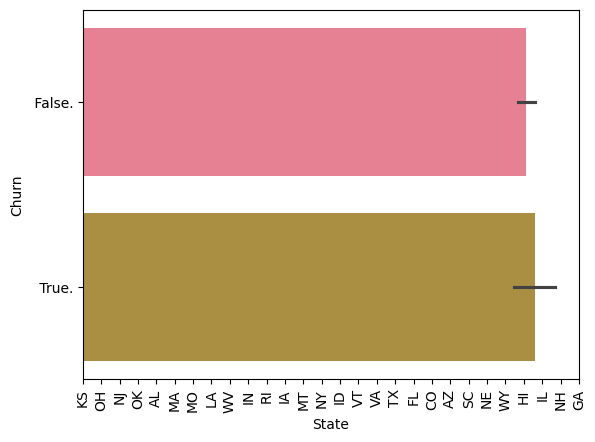

In [40]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.State,y = data1.Churn, orient='h',palette=palette) #create a bar plot graph analyzing

**Key Insights:**

- Churn Disparity: There is a significant difference in churn rates across different states.
- High Churn State: The gold bar represents a state with a noticeably higher churn rate compared to others.
- Low Churn State: The pink bar indicates a state with a relatively low churn rate.

<Axes: xlabel='Churn', ylabel='Account Length'>

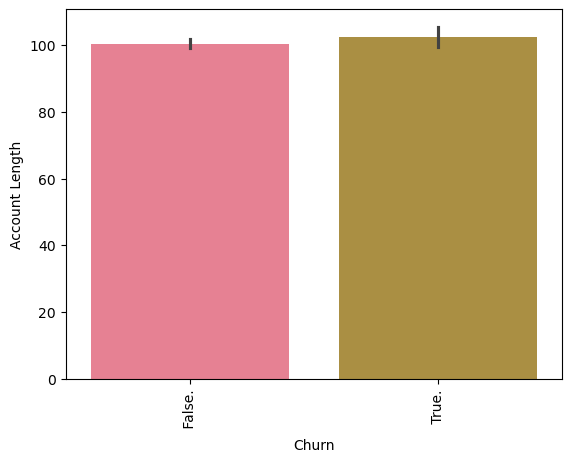

In [41]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['Account Length'],palette=palette) #create a bar plot graph analyzing

- The bar plot shows the distribution of account length for customers who churned (True) versus those who did not (False).

**Key Insights:**

- Account Length Distribution: The plot indicates that the majority of customers who churned had shorter account lengths compared to those who did not churn.
- Churn and Account Length: There seems to be a relationship between account length and churn, suggesting that customers with shorter account lengths are more likely to churn.

<Axes: xlabel='Churn', ylabel='International Plan'>

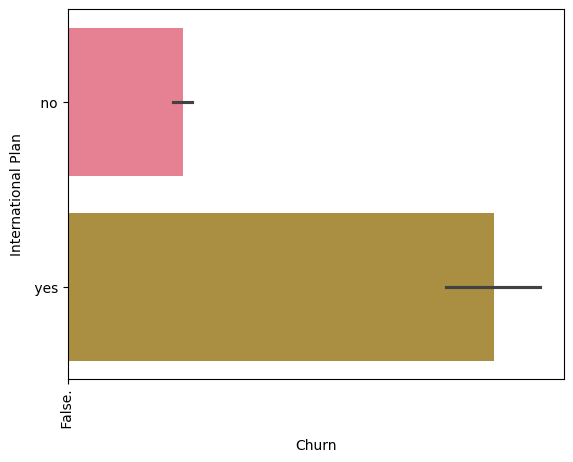

In [42]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['International Plan'],orient='h',palette=palette) #create a bar plot graph analyzing 

- The bar plot shows the distribution of customer churn based on whether they have an international plan or not.

**Key Insights:**

- Churn and International Plan: There seems to be a relationship between having an international plan and churn.
- Higher Churn: Customers with an international plan appear to have a higher churn rate compared to those without one.

<Axes: xlabel='Churn', ylabel='Day Mins'>

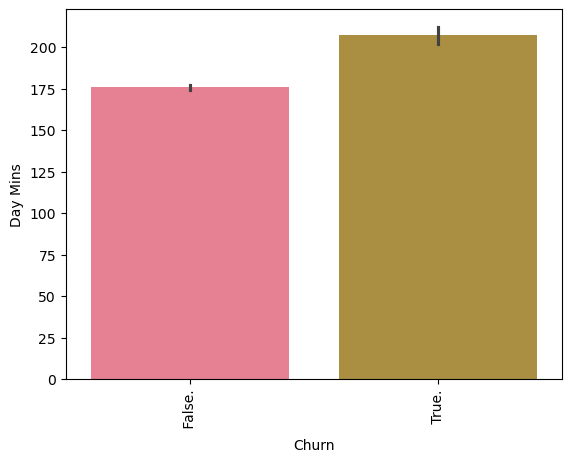

In [43]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['Day Mins'],palette=palette) #create a bar plot graph analyzing

- The bar plot shows the average number of day minutes used by customers who churned (True) versus those who did not (False).

**Key Insights:**

- Churn and Day Minutes: There appears to be a difference in the average number of day minutes used between churned and non-churned customers.
- Higher Usage: Customers who churned on average used more day minutes compared to those who did not churn.

<Axes: xlabel='Churn', ylabel='Day Calls'>

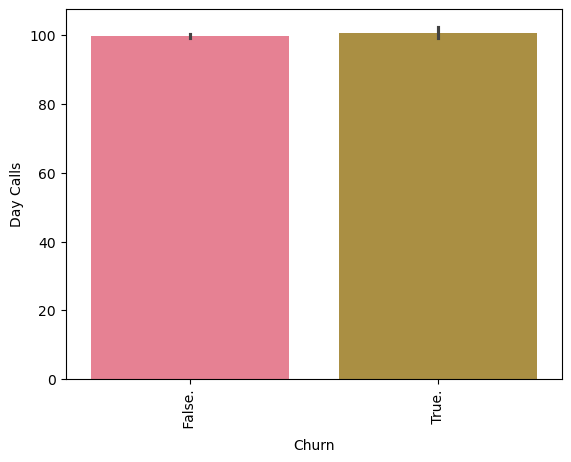

In [44]:
palette = sb.color_palette("husl")
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['Day Calls'],palette=palette) #create a bar plot graph analyzing

- The bar plot shows the average number of day calls made by customers who churned (True) versus those who did not (False).

**Key Insights:**

- Churn and Day Calls: There appears to be a difference in the average number of day calls made between churned and non-churned customers.
- Higher Calls: Customers who churned on average made more day calls compared to those who did not churn.

<Axes: xlabel='Churn', ylabel='Day Charge'>

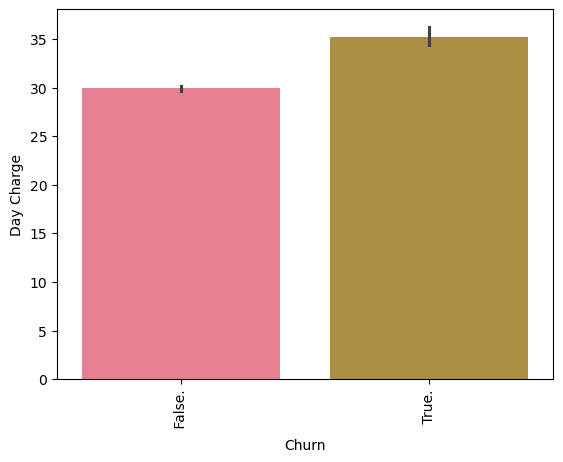

In [45]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['Day Charge'],palette=palette) #create a bar plot graph analyzing

- The bar plot shows the average day charge for customers who churned (True) versus those who did not (False).

**Key Insights:**

- Churn and Day Charge: There appears to be a difference in the average day charge between churned and non-churned customers.
- Higher Charge: Customers who churned on average had higher day charges compared to those who did not churn.

<Axes: xlabel='Churn', ylabel='Night Mins'>

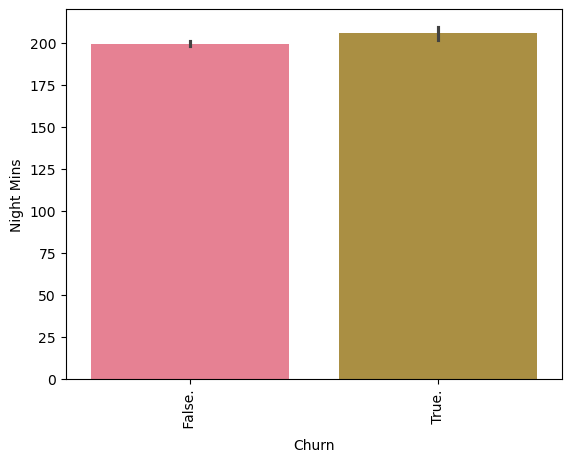

In [46]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['Night Mins'],palette=palette) #create a bar plot graph analyzing

- The bar plot shows the average night minutes used by customers who churned (True) versus those who did not (False).

**Key Insights:**

- Churn and Night Minutes: There appears to be a difference in the average night minutes used between churned and non-churned customers.
- Higher Usage: Customers who churned on average used more night minutes compared to those who did not churn.

<Axes: xlabel='Churn', ylabel='Night Calls'>

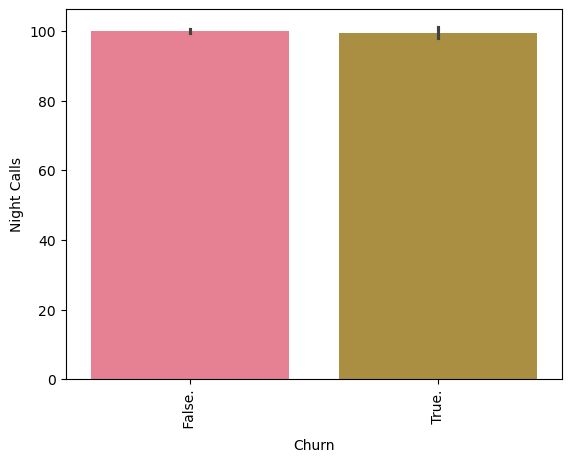

In [47]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['Night Calls'],palette=palette) #create a bar plot graph analyzing

- The bar plot shows the average number of night calls made by customers who churned (True) versus those who did not (False).

**Key Insights:**

- Churn and Night Calls: There appears to be a difference in the average number of night calls made between churned and non-churned customers.
- Higher Calls: Customers who churned on average made more night calls compared to those who did not churn.

<Axes: xlabel='Churn', ylabel='Night Charge'>

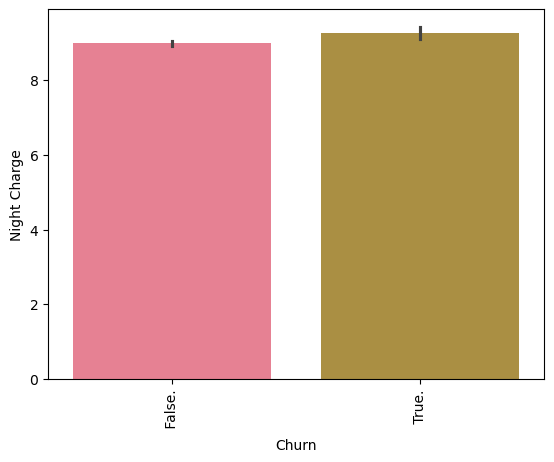

In [48]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['Night Charge'],palette=palette) #create a bar plot graph analyzing

- The bar plot shows the average night charge for customers who churned (True) versus those who did not (False).

**Key Insights:**

- Churn and Night Charge: There appears to be a difference in the average night charge between churned and non-churned customers.
- Higher Charge: Customers who churned on average had higher night charges compared to those who did not churn.

<Axes: xlabel='Churn', ylabel='International Mins'>

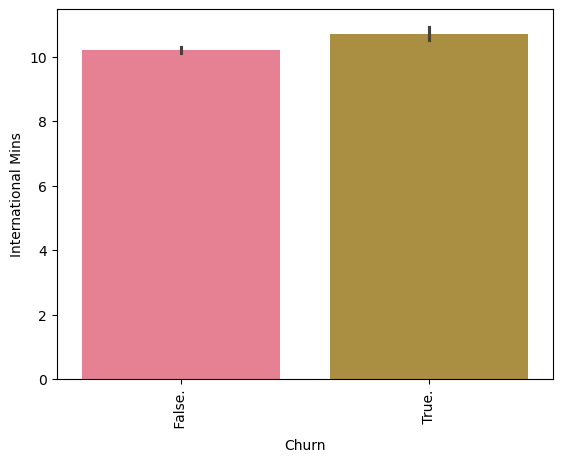

In [49]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['International Mins'],palette=palette) #create a bar plot graph analyzing

- he bar plot shows the average international minutes used by customers who churned (True) versus those who did not (False).

**Key Insights:**

- Churn and International Minutes: There appears to be a difference in the average international minutes used between churned and non-churned customers.
- Higher Usage: Customers who churned on average used more international minutes compared to those who did not churn.

<Axes: xlabel='Churn', ylabel='International Charge'>

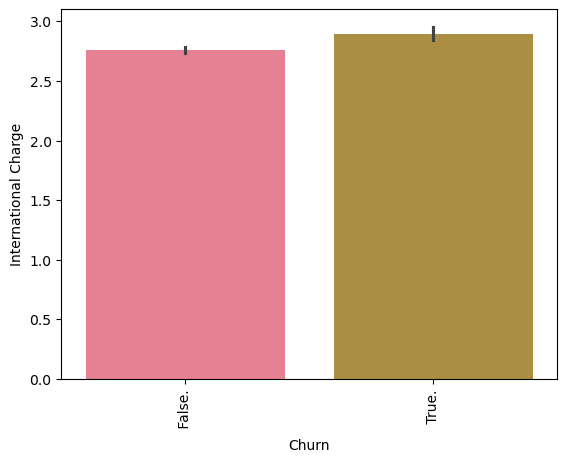

In [50]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['International Charge'],palette=palette) #create a bar plot graph analyzing

- The bar plot shows the average international charge for customers who churned (True) versus those who did not (False).

**Key Insights:**

- Churn and International Charge: There appears to be a difference in the average international charge between churned and non-churned customers.
- Higher Charge: Customers who churned on average had higher international charges compared to those who did not churn.

<Axes: xlabel='Churn', ylabel='CustServ Calls'>

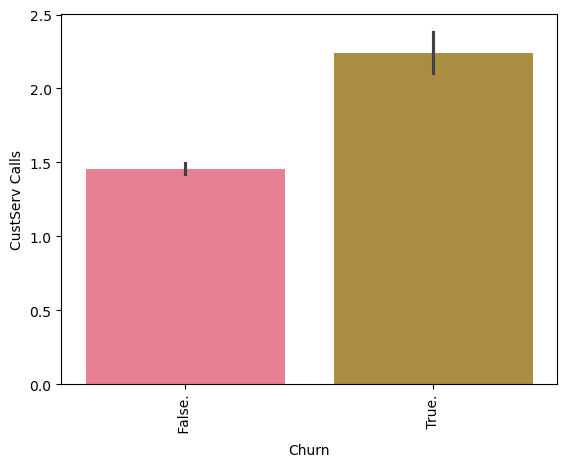

In [51]:
palette = sb.color_palette("husl") # use for bar color create
plt.xticks(rotation = 90)  # used for x axis value show in 90
sb.barplot(x = data1.Churn,y = data1['CustServ Calls'],palette=palette) #create a bar plot graph analyzing

-The bar plot shows the average customer service calls made by customers who churned (True) versus those who did not (False).

**Key Insights:**

- Churn and Customer Service Calls: There appears to be a difference in the average number of customer service calls made between churned and non-churned customers.
- Higher Calls: Customers who churned on average made more customer service calls compared to those who did not churn.

## Final Report of EDA

- Based on the analysis of various factors influencing customer churn, it is evident that several key areas contribute to customer attrition. Customers with higher usage of services like day minutes, evening minutes, night minutes, and international calls tend to churn more. Additionally, customers with higher charges and those who make more customer service calls are also more likely to churn.

- To mitigate churn, it is crucial to focus on improving customer satisfaction, especially for high-usage customers. This can be achieved by offering personalized pricing plans, enhancing customer support, and proactively addressing customer issues. By understanding the factors driving churn and implementing targeted strategies, the telecommunications company can significantly reduce customer attrition and improve overall business performance.

## Feature Engineering

**Feature Engineering:-** It is the process of using domain knowledge to select, modify, or create new features from raw data that can improve the performance of machine learning models. It involves transforming raw data into a format that is more suitable for modeling and can significantly impact model accuracy and effectiveness.

#### 1. Data Preprocessing:-

**Data Preprocessing:-** It is the comprehensive set of techniques and processes used to clean, transform, and organize raw data into a suitable format for analysis or machine learning. It is a critical step in the data analysis pipeline that ensures the quality and relevance of the data used for modeling.

In [56]:
data1.isnull().sum() #check the Null valuse

State                    0
Account Length           0
Area Code                0
Phone                    0
International Plan       0
VMail Plan               0
VMail Message            0
Day Mins                 0
Day Calls                0
Day Charge               0
Eve Mins                 0
Eve Calls                0
Eve Charge               0
Night Mins               0
Night Calls              0
Night Charge             0
International Mins       0
International calls      0
International Charge     0
CustServ Calls           0
Churn                    0
dtype: int64

- Here we can not see any null values.

In [60]:
data2 = data1[["Account Length","Area Code","VMail Message","Day Mins","Day Calls","Day Charge","Eve Mins","Eve Calls","Eve Charge","Night Mins","Night Calls","Night Charge","International Mins","CustServ Calls"]]

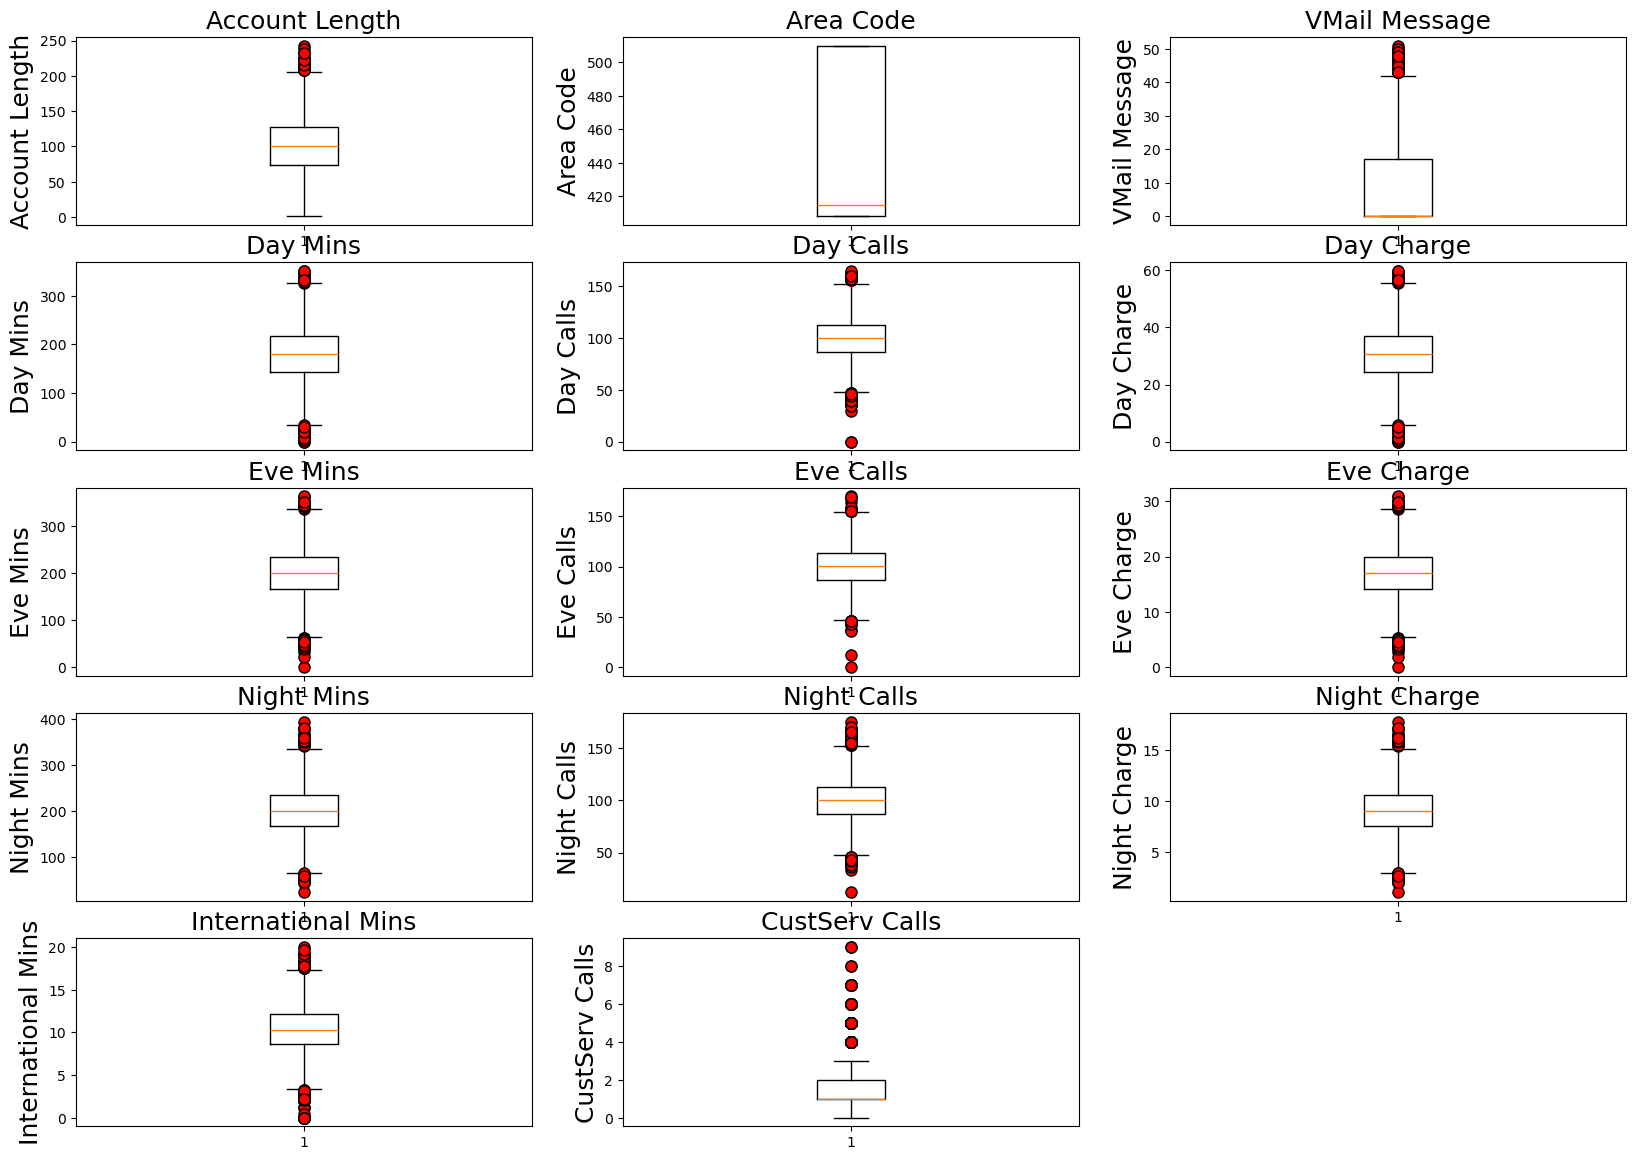

In [62]:
# here we are running a for loop for plot boxplot for all continous features.

plt.figure(figsize=(20,20)) #difine the columns size
plot_num = 1
flierprops = dict(marker='o', markerfacecolor='red', markersize=8)


for i in data2:
    if plot_num <= 14: # assighn the column value
        plt.subplot(7,3,plot_num) # row and column assighn
        plt.boxplot(data1[i],flierprops=flierprops)  # create the boxplot plot
        plot_num += 1
        plt.title(i, fontsize=18) #use for showing title
        plt.ylabel(i, fontsize=18) #define the font size of Y lable
        plt.title(i, fontsize=18)  #define the font size of title
        plt.show

<Axes: xlabel='Account Length'>

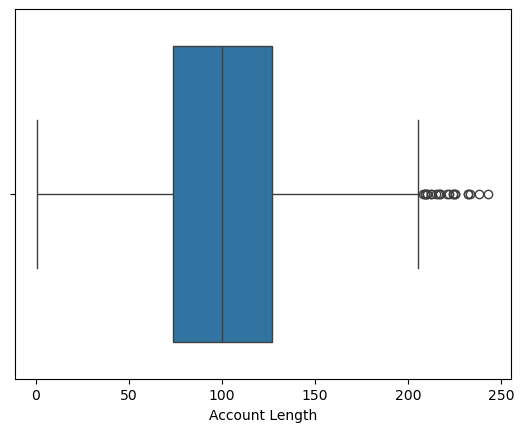

In [65]:
sb.boxplot(x = data2["Account Length"]) # check the outliers 

In [66]:
data2["Account Length"].mean() # find the mean

100.64522417153997

In [68]:
data2.loc[data2["Account Length"] > 200,"Account Length"] =  data2["Account Length"].mean() # find the mean# handle the outliers value

<Axes: xlabel='Account Length'>

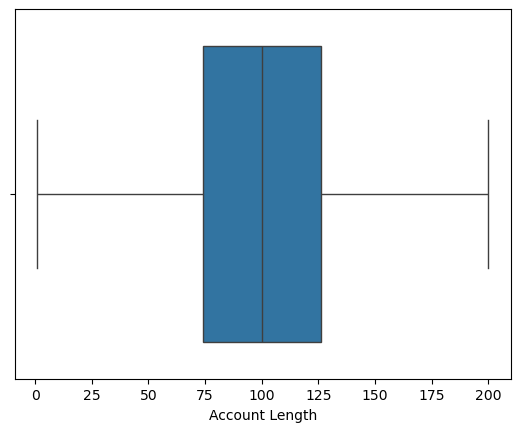

In [70]:
sb.boxplot(x = data2["Account Length"]) # check the outliers 

<Axes: xlabel='VMail Message'>

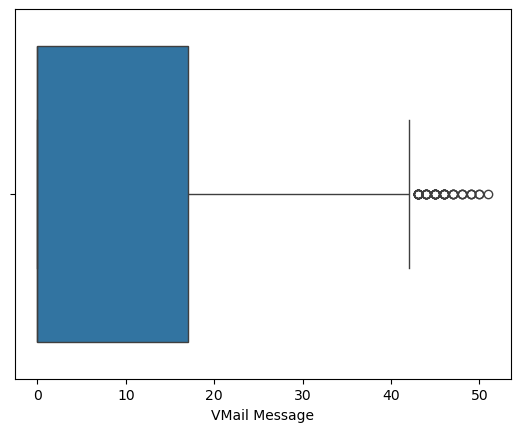

In [72]:
sb.boxplot(x = data2["VMail Message"]) # check the outliers 

In [73]:
data2["VMail Message"].mode() # find the mean

0    0
Name: VMail Message, dtype: int64

In [75]:
data2.loc[data2["VMail Message"] > 42,"VMail Message"] =  data2["VMail Message"].mean() # find the mean# handle the outliers value

<Axes: xlabel='Day Mins'>

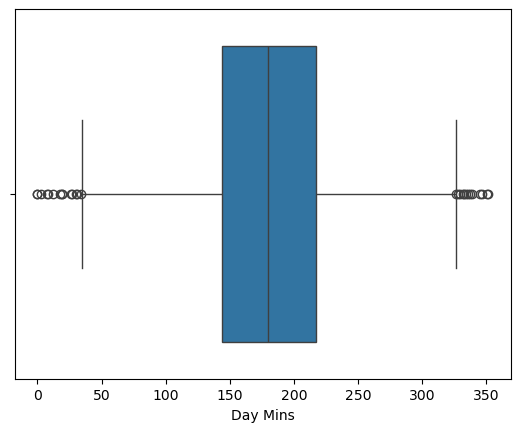

In [77]:
sb.boxplot(x = data2["Day Mins"]) # check the outliers 

In [79]:
 data2["Day Mins"].mean() #find the mean

180.44715183019275

In [81]:
data2.loc[(data2["Day Mins"] < 40) & (data2["Day Mins"] > 320), "Day Mins"] = data2["Day Mins"].mean() #handle the outliers value

<Axes: xlabel='Day Calls'>

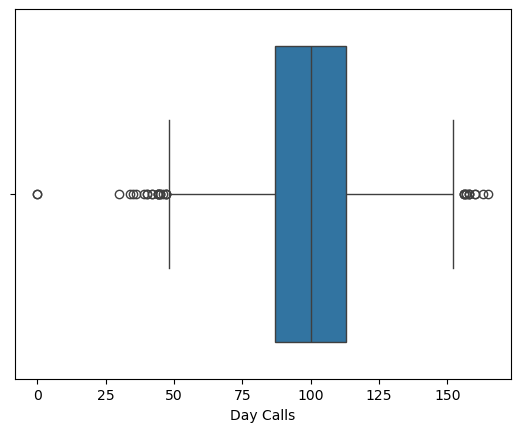

In [82]:
sb.boxplot(x = data2["Day Calls"]) # check the outliers 

In [84]:
data2.loc[(data2["Day Calls"] < 48), "Day Calls"] = data2["Day Calls"].mean() #handle the outliers value


In [86]:
data2.loc[(data2["Day Calls"] > 150), "Day Calls"] = data2["Day Calls"].mean() #handle the outliers value


<Axes: xlabel='Day Calls'>

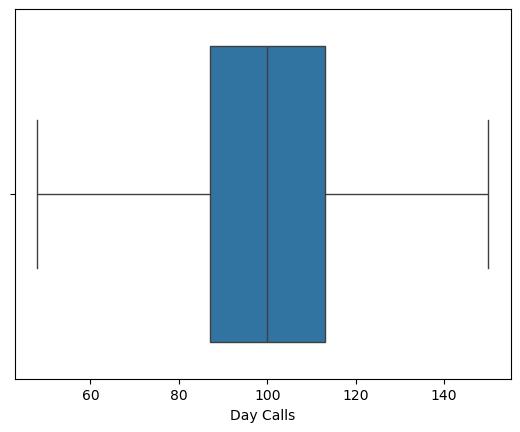

In [89]:
sb.boxplot(x = data2["Day Calls"]) # check the outliers 

<Axes: xlabel='Day Charge'>

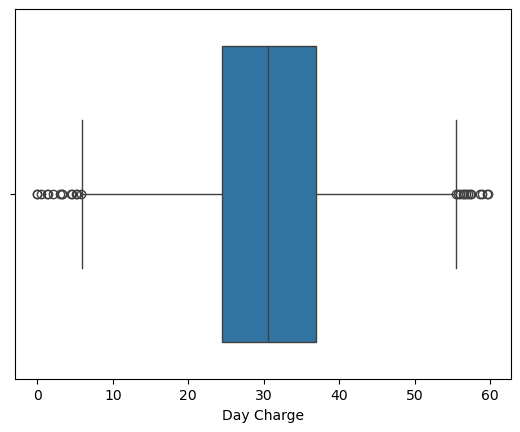

In [90]:
sb.boxplot(x = data2["Day Charge"]) # check the outliers 

In [91]:
data2.loc[(data2["Day Charge"] < 6), "Day Charge"] = data2["Day Charge"].mean()  #handle the outliers value


In [92]:
data2.loc[(data2["Day Charge"] > 55), "Day Charge"] = data2["Day Charge"].mean() #handle the outliers value


<Axes: xlabel='Day Charge'>

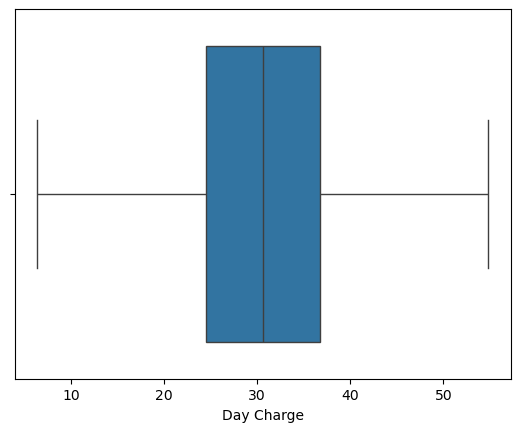

In [93]:
sb.boxplot(x = data2["Day Charge"]) # check the outliers 

<Axes: xlabel='Eve Mins'>

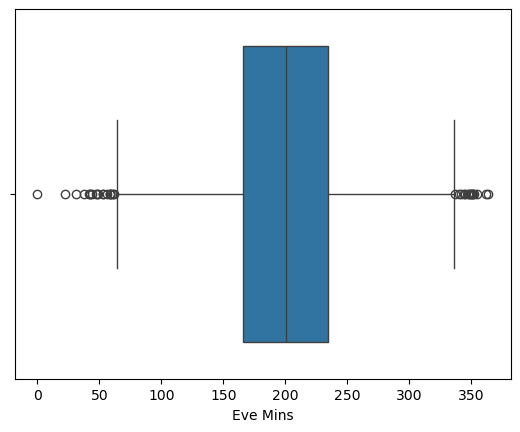

In [94]:
sb.boxplot(x = data2["Eve Mins"]) # check the outliers 

In [95]:
data2.loc[(data2["Eve Mins"] < 70), "Eve Mins"] = data2["Eve Mins"].mean()  #handle the outliers value

In [96]:
data2.loc[(data2["Eve Mins"] > 330), "Eve Mins"] = data2["Eve Mins"].mean() #handle the outliers value

<Axes: xlabel='Eve Mins'>

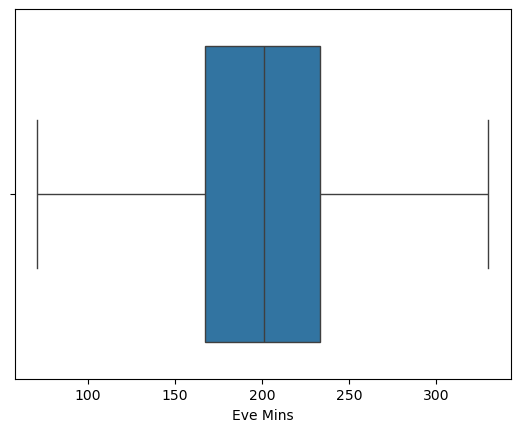

In [99]:
sb.boxplot(x = data2["Eve Mins"]) # check the outliers 

<Axes: xlabel='Eve Calls'>

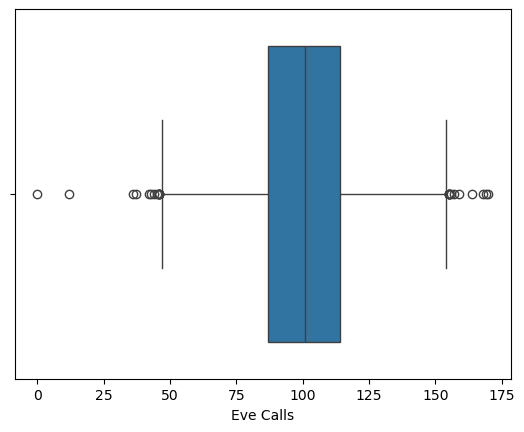

In [102]:
sb.boxplot(x = data2["Eve Calls"]) # check the outliers 

In [104]:
data2.loc[(data2["Eve Calls"] < 50), "Eve Calls"] = data2["Eve Calls"].mean()  #handle the outliers value

In [108]:
data2.loc[(data2["Eve Calls"] > 150), "Eve Calls"] = data2["Eve Calls"].mean() #handle the outliers value

<Axes: xlabel='Eve Calls'>

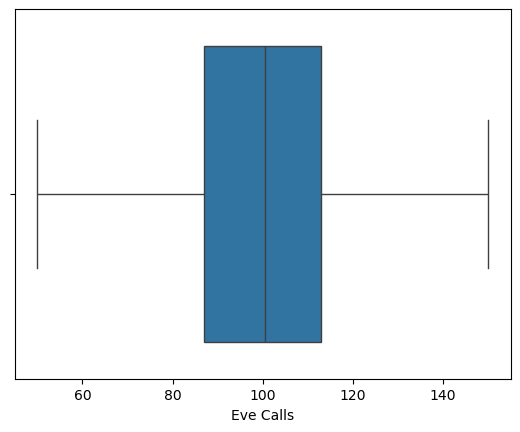

In [112]:
sb.boxplot(x = data2["Eve Calls"]) # check the outliers 

<Axes: xlabel='Eve Charge'>

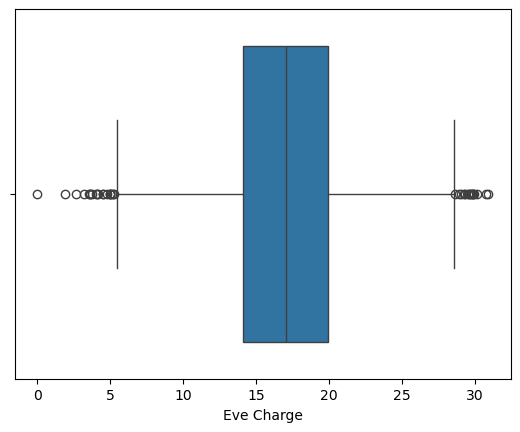

In [116]:
sb.boxplot(x = data2["Eve Charge"]) # check the outliers 

In [118]:
data2.loc[(data2["Eve Charge"] < 4), "Eve Charge"] = data2["Eve Charge"].mean() #handle the outliers value

In [123]:
data2.loc[(data2["Eve Charge"]> 28), "Eve Charge"] = data2["Eve Charge"].mean() #handle the outliers value

<Axes: xlabel='Eve Charge'>

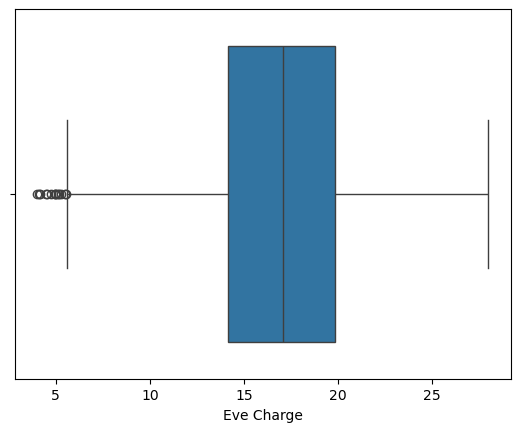

In [127]:
sb.boxplot(x = data2["Eve Charge"]) # check the outliers 

<Axes: xlabel='Night Mins'>

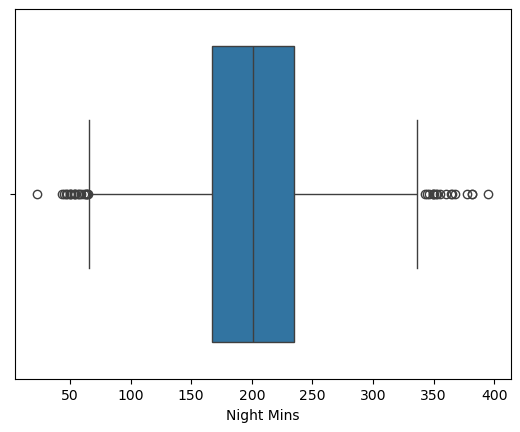

In [129]:
sb.boxplot(x = data2["Night Mins"]) # check the outliers 

In [133]:
data2.loc[(data2["Night Mins"] < 70), "Night Mins"] = data2["Night Mins"].mean() #handle the outliers value

In [134]:
data2.loc[(data2["Night Mins"] > 320), "Night Mins"] = data2["Night Mins"].mean() #handle the outliers value

<Axes: xlabel='Night Calls'>

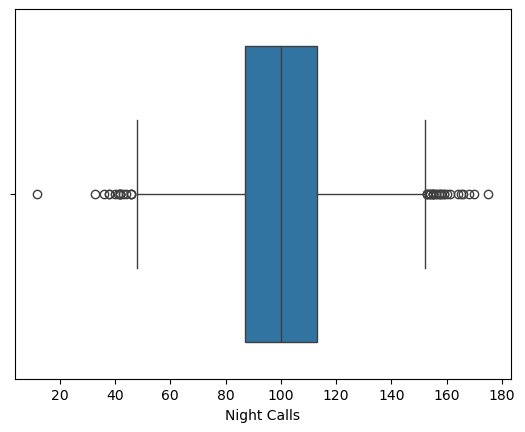

In [136]:
sb.boxplot(x = data2["Night Calls"]) # check the outliers 

In [140]:
data2.loc[(data2["Night Calls"] < 50), "Night Calls"] = data2["Night Calls"].mean() #handle the outliers value

In [142]:
data2.loc[(data2["Night Calls"] > 145), "Night Calls"] = data2["Night Calls"].mean() #handle the outliers value

<Axes: xlabel='Night Charge'>

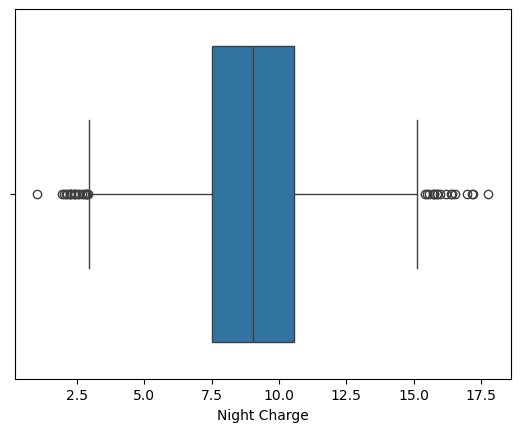

In [146]:
sb.boxplot(x = data2["Night Charge"]) # check the outliers 

In [148]:
data2.loc[(data2["Night Charge"] < 3.0), "Night Charge"] = data2["Night Charge"].mean() #handle the outliers value

In [151]:
data2.loc[(data2["Night Charge"] > 15.0), "Night Charge"] = data2["Night Charge"].mean() #handle the outliers value

<Axes: xlabel='International Mins'>

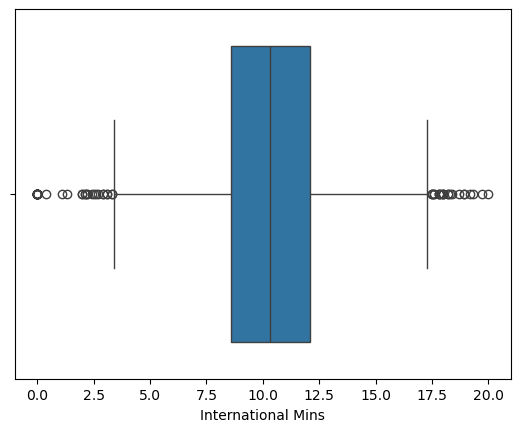

In [155]:
sb.boxplot(x = data2["International Mins"]) # check the outliers 

In [157]:
data2.loc[(data2["International Mins"] < 3.5), "International Mins"] = data2["International Mins"].mean() #handle the outliers value

In [159]:
data2.loc[(data2["International Mins"] > 17.1), "International Mins"] = data2["International Mins"].mean() #handle the outliers value

<Axes: xlabel='CustServ Calls'>

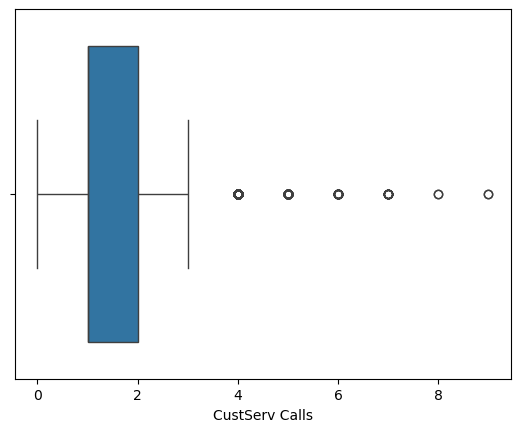

In [161]:
sb.boxplot(x = data2["CustServ Calls"]) # check the outliers 

In [163]:
data2["CustServ Calls"].mean() #find the mean

1.5670348711284383

In [165]:
data2["CustServ Calls"].median()  #finding the median

1.0

In [167]:
data2

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,CustServ Calls
0,128.0,415,25.0,265.1,110.0,45.07,197.400000,99.0,16.78,244.7,91.0,11.01,10.0,1
1,107.0,415,26.0,161.6,123.0,27.47,195.500000,103.0,16.62,254.4,103.0,11.45,13.7,1
2,137.0,415,0.0,243.4,114.0,41.38,121.200000,110.0,10.30,162.6,104.0,7.32,12.2,0
3,84.0,408,0.0,299.4,71.0,50.90,200.429088,88.0,5.26,196.9,89.0,8.86,6.6,2
4,75.0,415,0.0,166.7,113.0,28.34,148.300000,122.0,12.61,186.9,121.0,8.41,10.1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57.0,510,25.0,144.0,81.0,24.48,187.200000,112.0,15.91,158.6,122.0,7.14,8.5,3
4613,177.0,408,29.0,189.0,91.0,32.13,303.100000,96.0,25.76,163.6,116.0,7.36,15.7,3
4614,67.0,408,33.0,127.5,126.0,21.68,296.100000,129.0,25.17,200.9,91.0,9.04,13.0,1
4615,98.0,415,23.0,168.9,98.0,28.71,226.300000,117.0,19.24,165.5,96.0,7.45,14.3,0


#### Encoding :-

* So basically we have some columns which has data into categorical. So, we have to change that into numerical. Because our machine don't understand categorical data.
  
* To convert categorical data into numerical we have some technique which are,

**There are three types:-** 
1. Label Encoder
2. Ordinal Encoder
3. One Hot Encoder

In [169]:
from sklearn.preprocessing import LabelEncoder  #importing LabelEncoder
lb = LabelEncoder()  # call the label encoder   

In [171]:
data1["International Plan"] 

0         no
1         no
2         no
3        yes
4        yes
        ... 
4612      no
4613      no
4614      no
4615      no
4616      no
Name: International Plan, Length: 4617, dtype: object

In [173]:
data1["International Plan"] =  lb.fit_transform(data1["International Plan"]) # here we are tranforming categorical data into numerical using label encoder

In [175]:
data1

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,0,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,0,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,0,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,1,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,1,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,0,yes,25,144.0,81,24.48,...,112,15.91,158.6,122,7.14,8.5,6,2.30,3,False.
4613,NM,177,408,343-6820,0,yes,29,189.0,91,32.13,...,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,0,yes,33,127.5,126,21.68,...,129,25.17,200.9,91,9.04,13.0,3,3.51,1,False.
4615,MI,98,415,355-8388,0,yes,23,168.9,98,28.71,...,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.


In [177]:
data1["VMail Plan"]

0        yes
1        yes
2         no
3         no
4         no
        ... 
4612     yes
4613     yes
4614     yes
4615     yes
4616      no
Name: VMail Plan, Length: 4617, dtype: object

In [179]:
data1["VMail Plan"] =  lb.fit_transform(data1["VMail Plan"]) # here we are tranforming categorical data into numerical using label encoder

In [181]:
data1["Churn"] =  lb.fit_transform(data1["Churn"]) # here we are tranforming categorical data into numerical using label encoder

In [183]:
data1

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,0,1,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,371-7191,0,1,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,358-1921,0,0,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,375-9999,1,0,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,330-6626,1,0,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,0,1,25,144.0,81,24.48,...,112,15.91,158.6,122,7.14,8.5,6,2.30,3,0
4613,NM,177,408,343-6820,0,1,29,189.0,91,32.13,...,96,25.76,163.6,116,7.36,15.7,1,4.24,3,0
4614,VT,67,408,338-4794,0,1,33,127.5,126,21.68,...,129,25.17,200.9,91,9.04,13.0,3,3.51,1,0
4615,MI,98,415,355-8388,0,1,23,168.9,98,28.71,...,117,19.24,165.5,96,7.45,14.3,3,3.86,0,0


In [185]:
data2 = data1.drop("Phone",axis=1) # drop the column high corelation
data2

,State,Account Length,Area Code,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,0,1,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3,0
4613,NM,177,408,0,1,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,0
4614,VT,67,408,0,1,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1,0
4615,MI,98,415,0,1,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,0


In [187]:
data2 = data2.drop("State",axis=1) # drop the column high corelation
data2

,Account Length,Area Code,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,0,1,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3,0
4613,177,408,0,1,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,0
4614,67,408,0,1,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1,0
4615,98,415,0,1,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,0


<Axes: >

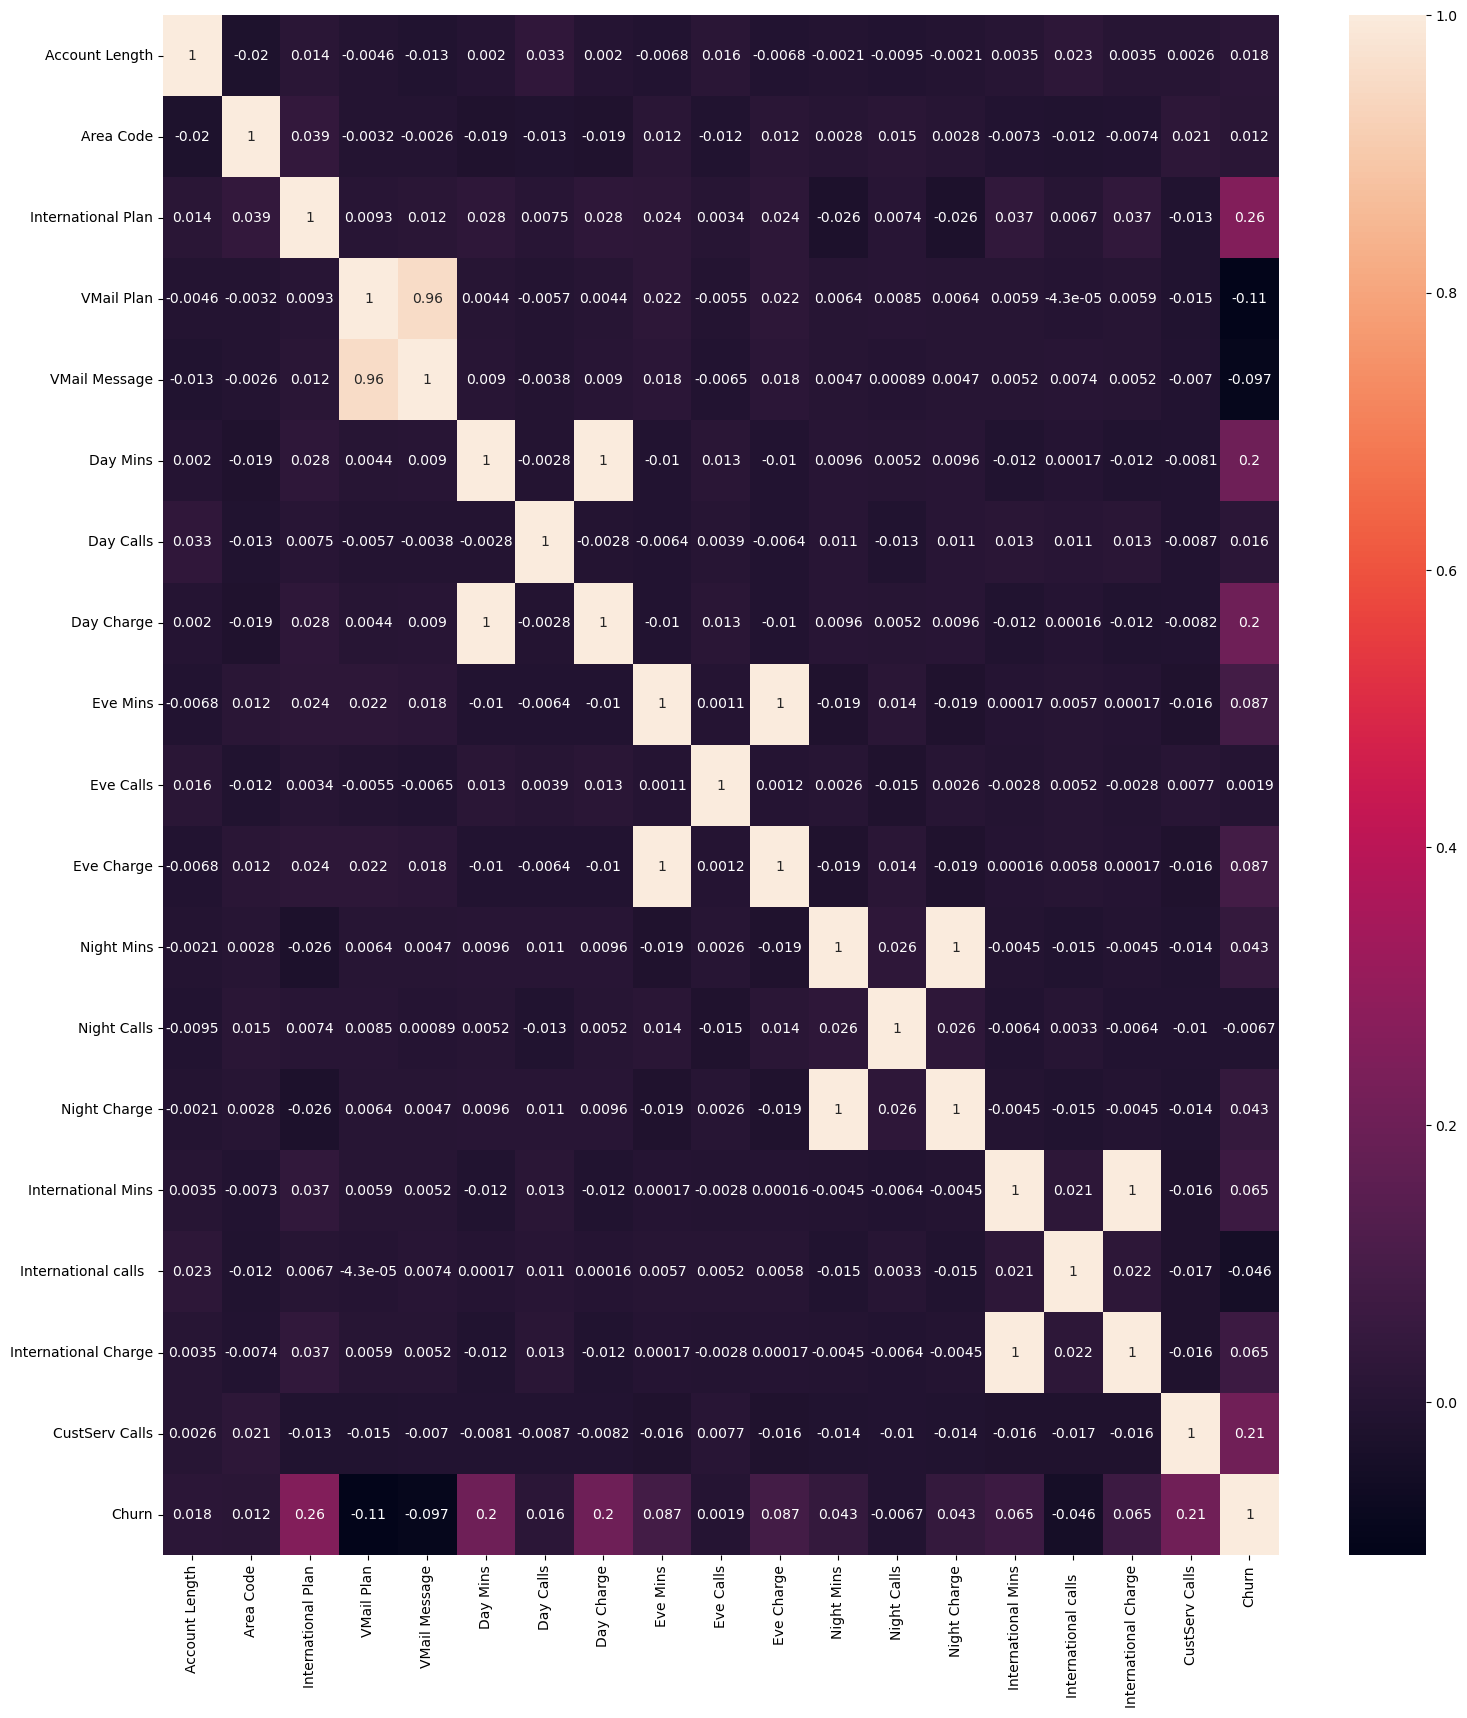

In [189]:
plt.figure(figsize=(18,20)) # define the plot size
sb.heatmap(data2.corr(),annot=True) # craete a heatmap check the relationship

In [191]:
data3 = data2.drop("Eve Calls",axis=1) # drop the column high corelation
data3

,Account Length,Area Code,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,128,415,0,1,25,265.1,110,45.07,197.4,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,415,0,1,26,161.6,123,27.47,195.5,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,415,0,0,0,243.4,114,41.38,121.2,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,1,0,0,299.4,71,50.90,61.9,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,415,1,0,0,166.7,113,28.34,148.3,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,0,1,25,144.0,81,24.48,187.2,15.91,158.6,122,7.14,8.5,6,2.30,3,0
4613,177,408,0,1,29,189.0,91,32.13,303.1,25.76,163.6,116,7.36,15.7,1,4.24,3,0
4614,67,408,0,1,33,127.5,126,21.68,296.1,25.17,200.9,91,9.04,13.0,3,3.51,1,0
4615,98,415,0,1,23,168.9,98,28.71,226.3,19.24,165.5,96,7.45,14.3,3,3.86,0,0


In [193]:
data4 = data3.drop("Night Calls",axis=1) # drop the column high corelation
data4

,Account Length,Area Code,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,128,415,0,1,25,265.1,110,45.07,197.4,16.78,244.7,11.01,10.0,3,2.70,1,0
1,107,415,0,1,26,161.6,123,27.47,195.5,16.62,254.4,11.45,13.7,3,3.70,1,0
2,137,415,0,0,0,243.4,114,41.38,121.2,10.30,162.6,7.32,12.2,5,3.29,0,0
3,84,408,1,0,0,299.4,71,50.90,61.9,5.26,196.9,8.86,6.6,7,1.78,2,0
4,75,415,1,0,0,166.7,113,28.34,148.3,12.61,186.9,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,0,1,25,144.0,81,24.48,187.2,15.91,158.6,7.14,8.5,6,2.30,3,0
4613,177,408,0,1,29,189.0,91,32.13,303.1,25.76,163.6,7.36,15.7,1,4.24,3,0
4614,67,408,0,1,33,127.5,126,21.68,296.1,25.17,200.9,9.04,13.0,3,3.51,1,0
4615,98,415,0,1,23,168.9,98,28.71,226.3,19.24,165.5,7.45,14.3,3,3.86,0,0


In [195]:
data5 = data4.drop("Day Calls",axis=1) # drop the column high corelation
data5

,Account Length,Area Code,International Plan,VMail Plan,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,128,415,0,1,25,265.1,45.07,197.4,16.78,244.7,11.01,10.0,3,2.70,1,0
1,107,415,0,1,26,161.6,27.47,195.5,16.62,254.4,11.45,13.7,3,3.70,1,0
2,137,415,0,0,0,243.4,41.38,121.2,10.30,162.6,7.32,12.2,5,3.29,0,0
3,84,408,1,0,0,299.4,50.90,61.9,5.26,196.9,8.86,6.6,7,1.78,2,0
4,75,415,1,0,0,166.7,28.34,148.3,12.61,186.9,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,0,1,25,144.0,24.48,187.2,15.91,158.6,7.14,8.5,6,2.30,3,0
4613,177,408,0,1,29,189.0,32.13,303.1,25.76,163.6,7.36,15.7,1,4.24,3,0
4614,67,408,0,1,33,127.5,21.68,296.1,25.17,200.9,9.04,13.0,3,3.51,1,0
4615,98,415,0,1,23,168.9,28.71,226.3,19.24,165.5,7.45,14.3,3,3.86,0,0


In [197]:
data5

,Account Length,Area Code,International Plan,VMail Plan,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,128,415,0,1,25,265.1,45.07,197.4,16.78,244.7,11.01,10.0,3,2.70,1,0
1,107,415,0,1,26,161.6,27.47,195.5,16.62,254.4,11.45,13.7,3,3.70,1,0
2,137,415,0,0,0,243.4,41.38,121.2,10.30,162.6,7.32,12.2,5,3.29,0,0
3,84,408,1,0,0,299.4,50.90,61.9,5.26,196.9,8.86,6.6,7,1.78,2,0
4,75,415,1,0,0,166.7,28.34,148.3,12.61,186.9,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,0,1,25,144.0,24.48,187.2,15.91,158.6,7.14,8.5,6,2.30,3,0
4613,177,408,0,1,29,189.0,32.13,303.1,25.76,163.6,7.36,15.7,1,4.24,3,0
4614,67,408,0,1,33,127.5,21.68,296.1,25.17,200.9,9.04,13.0,3,3.51,1,0
4615,98,415,0,1,23,168.9,28.71,226.3,19.24,165.5,7.45,14.3,3,3.86,0,0


## Model Selection

In [200]:
x = data5.drop("Churn",axis=1) # create the independent variable
y = data5["Churn"]  # create the dependent variable 

In [202]:
x # Show the independent variable

,Account Length,Area Code,International Plan,VMail Plan,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International calls,International Charge,CustServ Calls
0,128,415,0,1,25,265.1,45.07,197.4,16.78,244.7,11.01,10.0,3,2.70,1
1,107,415,0,1,26,161.6,27.47,195.5,16.62,254.4,11.45,13.7,3,3.70,1
2,137,415,0,0,0,243.4,41.38,121.2,10.30,162.6,7.32,12.2,5,3.29,0
3,84,408,1,0,0,299.4,50.90,61.9,5.26,196.9,8.86,6.6,7,1.78,2
4,75,415,1,0,0,166.7,28.34,148.3,12.61,186.9,8.41,10.1,3,2.73,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,0,1,25,144.0,24.48,187.2,15.91,158.6,7.14,8.5,6,2.30,3
4613,177,408,0,1,29,189.0,32.13,303.1,25.76,163.6,7.36,15.7,1,4.24,3
4614,67,408,0,1,33,127.5,21.68,296.1,25.17,200.9,9.04,13.0,3,3.51,1
4615,98,415,0,1,23,168.9,28.71,226.3,19.24,165.5,7.45,14.3,3,3.86,0


In [204]:
y # show the dependent variable

0       0
1       0
2       0
3       0
4       0
       ..
4612    0
4613    0
4614    0
4615    0
4616    0
Name: Churn, Length: 4617, dtype: int32

In [206]:
df = data5[["Account Length","Area Code","Day Mins","VMail Message","Day Charge","Eve Mins","Eve Charge","Night Mins","Night Charge","International Mins","International Charge"]]

In [208]:
# Data Tranfore to the certain range use Scaller
from sklearn.preprocessing import MinMaxScaler  #Import the  MinMaxScaler class from sklearn
SE = MinMaxScaler()  #Create an instance of the MinMaxScaler
df = SE.fit_transform(df)  #Fit the scaler to the x DataFrame and transform the data 

In [210]:
df

array([[0.52479339, 0.06862745, 0.7541963 , ..., 0.59593545, 0.5       ,
        0.5       ],
       [0.43801653, 0.06862745, 0.45974395, ..., 0.62223551, 0.685     ,
        0.68518519],
       [0.56198347, 0.06862745, 0.69246088, ..., 0.37537358, 0.61      ,
        0.60925926],
       ...,
       [0.27272727, 0.        , 0.36273115, ..., 0.4781829 , 0.65      ,
        0.65      ],
       [0.40082645, 0.06862745, 0.48051209, ..., 0.38314405, 0.715     ,
        0.71481481],
       [0.57438017, 0.06862745, 0.58236131, ..., 0.48356246, 0.605     ,
        0.60555556]])

In [212]:
x.columns #Get the column names of the DataFrame containing the x.

Index(['Account Length', 'Area Code', 'International Plan', 'VMail Plan',
       'VMail Message', 'Day Mins', 'Day Charge', 'Eve Mins', 'Eve Charge',
       'Night Mins', 'Night Charge', 'International Mins',
       'International calls  ', 'International Charge', 'CustServ Calls'],
      dtype='object')

In [214]:
# store scall data in Dataframe
Scaled_data = pd.DataFrame(data = df,columns=['Account Length', 'Area Code',
       'VMail Message', 'Day Mins', 'Day Charge', 'Eve Mins', 'Eve Charge',
       'Night Mins', 'Night Charge', 'International Mins',
       'International Charge']) 

In [216]:
Unscaled_data = pd.DataFrame(data=data5,columns=['International Plan','VMail Plan','International calls','CustServ Calls'])

In [218]:
data6 = pd.concat([Scaled_data,Unscaled_data],axis=1)

In [220]:
data6.head()

,Account Length,Area Code,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International Charge,International Plan,VMail Plan,International calls,CustServ Calls
0,0.524793,0.068627,0.754196,0.490196,0.754183,0.542755,0.542866,0.595750,0.595935,0.500,0.500000,0,1,NaN,1
1,0.438017,0.068627,0.459744,0.509804,0.459672,0.537531,0.537690,0.621840,0.622236,0.685,0.685185,0,1,NaN,1
2,0.561983,0.068627,0.692461,0.000000,0.692436,0.333242,0.333225,0.374933,0.375374,0.610,0.609259,0,0,NaN,0
3,0.342975,0.000000,0.851778,0.000000,0.851740,0.170195,0.170171,0.467187,0.467424,0.330,0.329630,1,0,NaN,2
4,0.305785,0.068627,0.474253,0.000000,0.474230,0.407754,0.407959,0.440290,0.440526,0.505,0.505556,1,0,NaN,3


In [222]:
data7=data6.drop('International calls', axis=1, inplace=True)

In [224]:
data7=data6

In [226]:
data7.head()

,Account Length,Area Code,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International Charge,International Plan,VMail Plan,CustServ Calls
0,0.524793,0.068627,0.754196,0.490196,0.754183,0.542755,0.542866,0.595750,0.595935,0.500,0.500000,0,1,1
1,0.438017,0.068627,0.459744,0.509804,0.459672,0.537531,0.537690,0.621840,0.622236,0.685,0.685185,0,1,1
2,0.561983,0.068627,0.692461,0.000000,0.692436,0.333242,0.333225,0.374933,0.375374,0.610,0.609259,0,0,0
3,0.342975,0.000000,0.851778,0.000000,0.851740,0.170195,0.170171,0.467187,0.467424,0.330,0.329630,1,0,2
4,0.305785,0.068627,0.474253,0.000000,0.474230,0.407754,0.407959,0.440290,0.440526,0.505,0.505556,1,0,3


In [228]:
#creat the dependent and independent variable
x1 = data7
y1 = data5["Churn"]

In [230]:
x1

,Account Length,Area Code,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International Charge,International Plan,VMail Plan,CustServ Calls
0,0.524793,0.068627,0.754196,0.490196,0.754183,0.542755,0.542866,0.595750,0.595935,0.500,0.500000,0,1,1
1,0.438017,0.068627,0.459744,0.509804,0.459672,0.537531,0.537690,0.621840,0.622236,0.685,0.685185,0,1,1
2,0.561983,0.068627,0.692461,0.000000,0.692436,0.333242,0.333225,0.374933,0.375374,0.610,0.609259,0,0,0
3,0.342975,0.000000,0.851778,0.000000,0.851740,0.170195,0.170171,0.467187,0.467424,0.330,0.329630,1,0,2
4,0.305785,0.068627,0.474253,0.000000,0.474230,0.407754,0.407959,0.440290,0.440526,0.505,0.505556,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,0.231405,1.000000,0.409673,0.490196,0.409639,0.514710,0.514720,0.364174,0.364614,0.425,0.425926,0,1,3
4613,0.727273,0.000000,0.537696,0.568627,0.537651,0.833379,0.833387,0.377622,0.377764,0.785,0.785185,0,1,3
4614,0.272727,0.000000,0.362731,0.647059,0.362784,0.814133,0.814300,0.477945,0.478183,0.650,0.650000,0,1,1
4615,0.400826,0.068627,0.480512,0.450980,0.480422,0.622216,0.622452,0.382733,0.383144,0.715,0.714815,0,1,0


In [232]:
y1

0       0
1       0
2       0
3       0
4       0
       ..
4612    0
4613    0
4614    0
4615    0
4616    0
Name: Churn, Length: 4617, dtype: int32

In [234]:
from sklearn.model_selection import train_test_split  #Import the train_test_split function from sklearn.model_selection
x_train,x_test,y_train,y_test = train_test_split(x1,y1,test_size=0.25,random_state=9) 
#Split the dataset into training and testing sets
#test_size=0.25: 25% of the data will be used for testing
#random_state=9: Ensures reproducibility of the split

In [236]:
x_train #training data

,Account Length,Area Code,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International Charge,International Plan,VMail Plan,CustServ Calls
4341,0.309917,0.068627,0.542817,0.725490,0.542838,0.610118,0.610159,0.505648,0.505678,0.615,0.614815,0,1,1
1912,0.421488,0.000000,0.428450,0.000000,0.428380,0.464944,0.464898,0.532544,0.532576,0.520,0.520370,0,0,8
4400,0.351240,1.000000,0.605405,0.000000,0.605422,0.249931,0.250081,0.347230,0.347280,0.595,0.594444,0,0,2
2054,0.367769,0.000000,0.398862,0.000000,0.398762,0.588122,0.588159,0.260355,0.260610,0.355,0.355556,0,0,1
1392,0.413223,0.068627,0.767283,0.000000,0.767236,0.570800,0.571013,0.513717,0.514047,0.225,0.225926,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,0.148760,0.068627,0.303272,0.000000,0.303213,0.405279,0.405370,0.571813,0.572026,0.480,0.479630,1,0,2
1787,0.599174,0.000000,0.576102,0.607843,0.576138,0.663734,0.663863,0.393760,0.393903,0.390,0.390741,0,1,1
501,0.508264,0.068627,0.715220,0.549020,0.715194,0.618917,0.618894,0.615116,0.615660,0.375,0.375926,0,1,1
4444,0.256198,0.068627,0.655192,0.490196,0.655120,0.455320,0.455516,0.550027,0.550508,0.450,0.450000,0,1,1


In [238]:
x_test #testing data

,Account Length,Area Code,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International Charge,International Plan,VMail Plan,CustServ Calls
4006,0.483471,0.000000,0.661166,0.000000,0.661145,0.525158,0.525396,0.510490,0.510460,0.385,0.385185,0,0,1
1424,0.318182,0.000000,0.400284,0.000000,0.400268,0.536706,0.536720,0.617805,0.618051,0.585,0.585185,0,0,0
588,0.413223,0.000000,0.255192,0.000000,0.255187,0.715150,0.715302,0.395105,0.395099,0.675,0.675926,0,0,5
2937,0.392562,0.068627,0.308962,0.784314,0.308902,0.567501,0.567454,0.277300,0.277346,0.670,0.670370,0,1,0
1470,0.165289,0.068627,0.589758,0.803922,0.589692,0.377509,0.377548,0.248790,0.249253,0.295,0.294444,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2790,0.239669,0.000000,0.362447,0.529412,0.362450,0.284025,0.284050,0.379236,0.379558,0.455,0.455556,0,1,0
277,0.590909,0.000000,0.539972,0.941176,0.539993,0.339291,0.339372,0.513717,0.514047,0.325,0.325926,0,1,2
2067,0.380165,0.000000,0.467994,0.000000,0.468039,0.634864,0.635070,0.340775,0.341303,0.495,0.494444,0,0,4
2480,0.429752,0.068627,0.426743,0.000000,0.426707,0.807809,0.807829,0.611888,0.612074,0.515,0.514815,1,0,3


## Balancing

In [241]:
# Balance the Data Value
from imblearn.over_sampling import SMOTE
sm = SMOTE()
sm_x_train,sm_y_train = sm.fit_resample(x_train,y_train)

In [242]:
from collections import Counter # show the balance value
print("Before",Counter(y_train))
print("After",Counter(sm_y_train)) 

Before Counter({0: 2978, 1: 484})
After Counter({0: 2978, 1: 2978})


## Model Creation

## logistic Regression Algorithm

In [247]:
# use the logistic Regression
from sklearn.linear_model import LogisticRegression #Import the LogisticRegression class from sklearn.linear_model
LE = LogisticRegression() #Create an instance of the Logistic Regression model
LE.fit(sm_x_train,sm_y_train) #Fit the Logistic Regression model to the training data 

LogisticRegression()

In [249]:
y_lrpredict = LE.predict(x_test) # predict the data

In [251]:
y_lrpredict

array([0, 0, 1, ..., 1, 1, 0])

In [253]:
y_test #show the actual target values for the test set

4006    0
1424    0
588     1
2937    0
1470    0
       ..
2790    0
277     1
2067    0
2480    0
456     0
Name: Churn, Length: 1155, dtype: int32

In [255]:
# Import the Logistic Regression Metrics
from sklearn.metrics import accuracy_score,f1_score,classification_report,recall_score,precision_score,confusion_matrix 

In [257]:
a1=accuracy_score(y_test,y_lrpredict) #check the model accuracy 
a1

0.7722943722943723

In [259]:
f1_score(y_test,y_lrpredict) #check f1 score of model 

0.5191956124314442

In [261]:
print(classification_report(y_test,y_lrpredict)) ##show the classification report for the predictions made by the Logistic Regression model

              precision    recall  f1-score   support

           0       0.96      0.76      0.85       983
           1       0.38      0.83      0.52       172

    accuracy                           0.77      1155
   macro avg       0.67      0.79      0.69      1155
weighted avg       0.87      0.77      0.80      1155



In [263]:
accuracies = []

# Assuming x1 and y1 are your features and target variables
for random_state in range(1, 151):
    # Split the data with the current random_state
    x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.25, random_state=random_state)
    
    # Initialize and train the Logistic Regression model
    model = LogisticRegression(max_iter=1000)  # Increased max_iter to ensure convergence
    model.fit(x_train, y_train)  # Using x_train and y_train directly
    
    # Predict on the test set
    y_pred = model.predict(x_test)
    
    # Calculate accuracy and store it
    a10 = accuracy_score(y_test, y_pred)
    accuracies.append((random_state, a10))

# Find the best random_state with the highest accuracy
best_random_state, best_accuracy = max(accuracies, key=lambda x: x[1])

# Print the best random state and its accuracy
print(f"Best Random State: {best_random_state}, Best Accuracy: {best_accuracy:.4f}")

Best Random State: 15, Best Accuracy: 0.8840


## SVM :-Support Vectore Machine

In [301]:
from sklearn.svm import SVC # SVM model import
SV = SVC() #Create the Support Vector Classifier
SV.fit(sm_x_train,sm_y_train) # train the data value

SVC()

In [303]:
y_smpredict = SV.predict(x_test) # Model test Predict

In [305]:
a2=accuracy_score(y_test,y_smpredict) # model performance data accuracy
a2

0.8571428571428571

In [282]:
print(classification_report(y_test,y_smpredict)) #show the classification report for the predictions made by the svm model

              precision    recall  f1-score   support

           0       0.98      0.87      0.92       995
           1       0.51      0.88      0.65       160

    accuracy                           0.87      1155
   macro avg       0.75      0.87      0.78      1155
weighted avg       0.91      0.87      0.88      1155



In [288]:
accuracies = []

# Assuming x1 and y1 are your features and target variables
for random_state in range(1, 151):
    # Split the data with the current random_state
    x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.25, random_state=random_state)
    
    # Initialize and train the Logistic Regression model
    model = SVC(max_iter=1000)  # Increased max_iter to ensure convergence
    model.fit(x_train, y_train)  # Using x_train and y_train directly
    
    # Predict on the test set
    y_pred = model.predict(x_test)
    
    # Calculate accuracy and store it
    a10 = accuracy_score(y_test, y_pred)
    accuracies.append((random_state, a10))

# Find the best random_state with the highest accuracy
best_random_state, best_accuracy = max(accuracies, key=lambda x: x[1])

# Print the best random state and its accuracy
print(f"Best Random State: {best_random_state}, Best Accuracy: {best_accuracy:.4f}")

Best Random State: 13, Best Accuracy: 0.9203


## Descision Tree Algorithm

In [307]:
from sklearn.tree import DecisionTreeClassifier # import decision tree model
DC = DecisionTreeClassifier() #call the dt model 
DC.fit(sm_x_train,sm_y_train) # train the data

DecisionTreeClassifier()

In [309]:
y_dcpredict = DC.predict(x_test) # Model test Predict

In [311]:
a3 = accuracy_score(y_test,y_dcpredict) # model performance data accuracy

In [313]:
a3

0.9688311688311688

In [334]:
print(classification_report(y_test,y_dcpredict)) #show the classification report for the predictions made by the svm model

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       996
           1       0.10      0.11      0.10       159

    accuracy                           0.74      1155
   macro avg       0.48      0.48      0.48      1155
weighted avg       0.75      0.74      0.75      1155



## KNN Algorithm

In [315]:
from sklearn.neighbors import KNeighborsClassifier # import KNN model 
KNN = KNeighborsClassifier()  #call the KNN model
KNN.fit(sm_x_train,sm_y_train) # train the data

KNeighborsClassifier()

In [317]:
y_knnpredict = KNN.predict(x_test) # Model test Predict

In [319]:
a4 = accuracy_score(y_test,y_knnpredict)  # model performance data accuracy
a4

0.8683982683982684

In [308]:
print(classification_report(y_test,y_knnpredict)) # data Performance report

              precision    recall  f1-score   support

           0       0.99      0.87      0.93       995
           1       0.54      0.93      0.68       160

    accuracy                           0.88      1155
   macro avg       0.76      0.90      0.81      1155
weighted avg       0.92      0.88      0.89      1155



In [310]:
accuracies = []

# Assuming x1 and y1 are your features and target variables
for random_state in range(1, 30):
    # Split the data with the current random_state
    x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.25, random_state=random_state)
    
    # Initialize and train the Logistic Regression model
    model2 = KNeighborsClassifier()  # Increased max_iter to ensure convergence
    model2.fit(x_train, y_train)  # Using x_train and y_train directly
    
    # Predict on the test set
    y_pred = model2.predict(x_test)
    
    # Calculate accuracy and store it
    a12 = accuracy_score(y_test, y_pred)
    accuracies.append((random_state, a12))

# Find the best random_state with the highest accuracy
best_random_state, best_accuracy = max(accuracies, key=lambda x: x[1])

# Print the best random state and its accuracy
print(f"Best Random State: {best_random_state}, Best Accuracy: {best_accuracy:.4f}")

Best Random State: 13, Best Accuracy: 0.9247


## ANN:- Artificial Netural Network

In [321]:
from sklearn.neural_network import MLPClassifier # import ANN model
ANN = MLPClassifier()  # call the model 
ANN.fit(sm_x_train,sm_y_train) # train the data

MLPClassifier()

In [322]:
y_annpredict = ANN.predict(x_test)  # Model test Predict

In [323]:
a5 = accuracy_score(y_test,y_annpredict) # model performance data accuracy

In [324]:
a5

0.8987012987012987

In [332]:
print(classification_report(y_test,y_annpredict)) # data Performance report

              precision    recall  f1-score   support

           0       0.98      0.90      0.94       996
           1       0.59      0.91      0.72       159

    accuracy                           0.90      1155
   macro avg       0.79      0.90      0.83      1155
weighted avg       0.93      0.90      0.91      1155



In [323]:
accuracies = []

# Assuming x1 and y1 are your features and target variables
for random_state in range(1, 30):
    # Split the data with the current random_state
    x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.25, random_state=random_state)
    
    # Initialize and train the Logistic Regression model
    model2 = MLPClassifier()  # Increased max_iter to ensure convergence
    model2.fit(x_train, y_train)  # Using x_train and y_train directly
    
    # Predict on the test set
    y_pred = model2.predict(x_test)
    
    # Calculate accuracy and store it
    a12 = accuracy_score(y_test, y_pred)
    accuracies.append((random_state, a12))

# Find the best random_state with the highest accuracy
best_random_state, best_accuracy = max(accuracies, key=lambda x: x[1])

# Print the best random state and its accuracy
print(f"Best Random State: {best_random_state}, Best Accuracy: {best_accuracy:.4f}")

Best Random State: 13, Best Accuracy: 0.9429


## Bagging Algorithm

In [329]:
from sklearn.ensemble import BaggingClassifier # import bagging model
model = LogisticRegression()  #call the BG model 
BG = BaggingClassifier(model, n_estimators=10, random_state=50)
BG.fit(sm_x_train,sm_y_train) # train the data

BaggingClassifier(estimator=LogisticRegression(), random_state=50)

In [331]:
y_bggpredict = BG.predict(x_test) # Model test Predict

In [333]:
a6 = accuracy_score(y_test,y_bggpredict)  # model performance data accuracy
a6

0.7653679653679654

## Boosting Algorithm

In [335]:
from sklearn.ensemble import GradientBoostingClassifier # import gradiant boosting model
GB = GradientBoostingClassifier()  #call the gb model 
GB.fit(sm_x_train,sm_y_train) # train the data

GradientBoostingClassifier()

In [337]:
y_gbpredict = GB.predict(x_test) # Model test Predict

In [339]:
a7 = accuracy_score(y_test,y_gbpredict)  # model performance data accuracy
a7

0.9116883116883117

In [343]:
f1_score(y_test,y_gbpredict)  # data training accuracy

0.7431693989071039

In [345]:
print(classification_report(y_test,y_gbpredict)) # data Performance report

              precision    recall  f1-score   support

           0       0.98      0.93      0.95       996
           1       0.66      0.86      0.74       159

    accuracy                           0.92      1155
   macro avg       0.82      0.89      0.85      1155
weighted avg       0.93      0.92      0.92      1155



## AddaBoosting Algorithm

In [266]:
from sklearn.ensemble import AdaBoostClassifier # import the adaboost model
model = LogisticRegression()
AD = AdaBoostClassifier(model, n_estimators=50, random_state=42)
AD.fit(sm_x_train,sm_y_train) # train the data

AdaBoostClassifier(estimator=LogisticRegression(), random_state=42)

In [268]:
y_addpredict = AD.predict(x_test)  # Model test Predict

In [270]:
a8 = accuracy_score(y_test,y_addpredict) # model performance data accuracy
a8

0.7792207792207793

In [272]:
print(classification_report(y_test,y_addpredict)) # data Performance report

              precision    recall  f1-score   support

           0       0.95      0.78      0.86       995
           1       0.36      0.76      0.49       160

    accuracy                           0.78      1155
   macro avg       0.66      0.77      0.67      1155
weighted avg       0.87      0.78      0.81      1155



In [274]:
accuracies = []

# Assuming x1 and y1 are your features and target variables
for random_state in range(1, 30):
    # Split the data with the current random_state
    x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.25, random_state=random_state)
    
    # Initialize and train the Logistic Regression model
    model2 = AdaBoostClassifier()  # Increased max_iter to ensure convergence
    model2.fit(x_train, y_train)  # Using x_train and y_train directly
    
    # Predict on the test set
    y_pred = model2.predict(x_test)
    
    # Calculate accuracy and store it
    a12 = accuracy_score(y_test, y_pred)
    accuracies.append((random_state, a12))

# Find the best random_state with the highest accuracy
best_random_state, best_accuracy = max(accuracies, key=lambda x: x[1])

# Print the best random state and its accuracy
print(f"Best Random State: {best_random_state}, Best Accuracy: {best_accuracy:.4f}")

Best Random State: 13, Best Accuracy: 0.8996


## RandomForest Algorithm

In [279]:
from sklearn.ensemble import RandomForestClassifier  # import the RM model
RM = RandomForestClassifier() # call RM model
RM.fit(sm_x_train,sm_y_train) # train the model

RandomForestClassifier()

In [281]:
y_rm = RM.predict(x_test)  # predict the test data

In [283]:
a9=accuracy_score(y_test,y_rm) #check the model accuracy
a9

0.9792207792207792

In [285]:
f9=f1_score(y_test,y_rm) #check f1 score
f9

0.9254658385093167

In [287]:
print(classification_report(y_test,y_rm)) #show the classification report for the predictions made by the RM model

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       996
           1       0.91      0.94      0.93       159

    accuracy                           0.98      1155
   macro avg       0.95      0.96      0.96      1155
weighted avg       0.98      0.98      0.98      1155



In [293]:
y_rmtr = RM.predict(x_train)  #predictions on the training set 

In [295]:
accuracy_score(y_train,y_rmtr)  #check the model accuracy

0.9771808203350665

In [341]:
# check the all algorithm model perforamnce in table form
score = pd.DataFrame({"Model":["LogisticRegression","SVM","DecisionTree","KNN","ANN_MLP","Bagging","GradiantBoosting","AdaBoosting","RandomForest"],
                     "accuracy_score":[a1*100,a2*100,a3*100,a4*100,a5*100,a6*100,a7*100,a8*100,a9*100]
                     })
score

,Model,accuracy_score
0,LogisticRegression,77.229437
1,SVM,85.714286
2,DecisionTree,96.883117
3,KNN,86.839827
4,ANN_MLP,89.870130
5,Bagging,76.536797
6,GradiantBoosting,91.168831
7,AdaBoosting,77.922078
8,RandomForest,97.922078


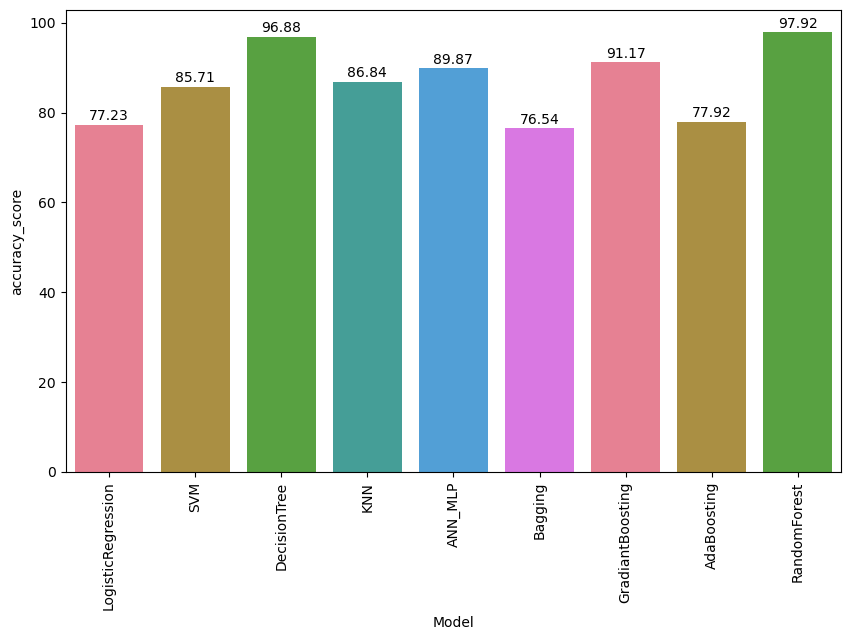

In [343]:
# use for All model performance show in barplot graph
palette = sb.color_palette("husl") # define the color for barplot 
plt.figure(figsize=(10, 6)) # define the plot size
plt.xticks(rotation = 90) # show the x axis value rotation
a = sb.barplot(x=score.Model, y=score.accuracy_score, data=score, palette=palette) # create the barplot

for index, value in enumerate(score['accuracy_score']): # show indivisual bar values show
    a.text(index, value + 1, f'{value:.2f}', ha='center')

## Final Conclusion of Model Report

* I have used total 9 Algorithm like LogisticRegression, SVM, DecisionTree, KNN, Bagging, RandomForest, GradientBoosting, ANN_MLP, AdaBoosting.

* Random Forest appears to be the top-performing model with an accuracy score of 97.92%. This indicates that it is capable of accurately predicting customer churn based on the given dataset.

* Decision Tree also performs well with an accuracy score of 96.00%. It might be a good choice if interpretability is a priority, as Decision Trees are relatively easy to understand.

* Gradient Boosting achieves an accuracy score of 91.17%, making it a strong contender for consideration.

* ANN MLP (Artificial Neural Network Multi-Layer Perceptron) and SVM (Support Vector Machine) also show promising results, suggesting their potential effectiveness in this context.

* Bagging and AdaBoosting seem to have lower accuracy scores compared to the other models, indicating they might not be the best choices for this specific project.

## Final Challenges of Report
**Outliers:**
Deciding whether to remove or cap outliers, as removing too many could lead to a loss of valuable data, especially if they represent rare but valid cases in your dataset.\
**Scaling:**
Ensuring that scaling was consistently applied across both training and test datasets was critical, as inconsistencies could impact model predictions.\
**Class Imbalance:**
Working with imbalanced data might have made it hard to build a model that performed well across all classes. The model might be biased towards the majority class, resulting in lower accuracy for minority classes.

Balancing techniques like SMOTE (Synthetic Minority Over-sampling Technique), undersampling, or adjusting class weights might have been considered or used to address this, but they could also introduce other issues like overfitting.\
**Accuracy Challenges:**
Deciding on the right evaluation metrics (e.g., accuracy, precision, recall, F1-score) could have been challenging, especially if accuracy alone didn’t fully capture model performance for imbalanced data.

In [348]:
import pickle #Importing the pickle module
with open("Churn.pkl","wb") as f: #Open the file "Heart.pkl" in write-binary mode
    pickle.dump(RM,f) #save it to the file

In [350]:
with open("Churn.pkl","rb") as f: # Open the file "Heart.pkl" in read-binary mode
    file = pickle.load(f) #load the file

In [352]:
file

RandomForestClassifier()

In [354]:
pwd

'C:\\Users\\Admin\\Downloads\\Datamites\\Internship project\\Data'

                                                        ! Thnak You !